# 데이터 입력
구글 드라이브에서 다운로드 후 압축 해제

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## firebase 인증

In [ ]:
!pip install firebase-admin

import firebase_admin
from firebase_admin import credentials, firestore

cred = credentials.Certificate('/content/drive/MyDrive/PosePick/security/firebase_key.json')
firebase_admin.initialize_app(cred)
db = firestore.client()

## 이미지 처리

In [ ]:
zip_path = "/content/drive/MyDrive/PosePick/BadPoseData/data_com.zip"

import zipfile
import os

# 1. 이미지가 들어있는 하위 selected 폴더까지 경로 지정
extract_path = "/content/drive/MyDrive/PosePick/bad/dataset" # 이렇게 해야지 이미지 경로가 "/content/drive/MyDrive/PosePick/good/dataset/selected"가 되더라고요.

with zipfile.ZipFile(zip_path, 'r') as zip_ref:

    zip_ref.extractall(extract_path)

1. 이미지를 똑바로 세우기가 필요할 때 rotate_and_overwrite_images(extract_path)를 실행해주시면 됩니다.

2. 파일명 변경이 필요할 때 rename_images_to_numeric(extract_path)를 실행해주시면 됩니다.

이 두 개는 필요할 수도 있고 필요없을 수도 있어서 아래의 코드에선 주석 처리해놨습니다. 필요할 때 주석을 풀어서 사용해주세요!

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

# 이미지 경로를 zip 파일명까지 적어야 합니다.
extract_path = "/content/drive/MyDrive/PosePick/bad/dataset/data_com"

# 이미지 물리적 회전 보정 함수
def rotate_and_overwrite_images(target_folder):
    """
    폴더 내 이미지들의 EXIF 회전 정보를 읽어 픽셀 자체를 물리적으로 회전시킨 후 덮어씁니다.
    """
    if not os.path.exists(target_folder):
        print(f"❌ 폴더가 존재하지 않습니다: {target_folder}")
        return

    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    files = [f for f in os.listdir(target_folder) if f.lower().endswith(valid_extensions)]

    print(f"🔄 이미지 방향 보정(물리적 회전) 시작: {len(files)}개 이미지")

    for filename in files:
        file_path = os.path.join(target_folder, filename)
        try:
            with Image.open(file_path) as img:
                # EXIF 정보를 바탕으로 이미지를 똑바로 세움
                fixed_img = ImageOps.exif_transpose(img)
                # 원본 파일에 덮어쓰기 (품질 유지)
                fixed_img.save(file_path, quality=95, subsampling=0)
        except Exception as e:
            print(f"⚠️ {filename} 처리 중 오류 발생: {e}")

    print(f"✨ 모든 이미지의 방향 보정 및 저장이 완료되었습니다.")

# 이미 압축 해제된 폴더 내의 이미지들을 0.jpg, 1.jpg 순으로 이름을 바꿉니다.
def rename_images_to_numeric(target_folder):
    if not os.path.exists(target_folder):
        print(f"❌ 폴더가 존재하지 않습니다: {target_folder}")
        return

    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    current_files = sorted([
        f for f in os.listdir(target_folder)
        if f.lower().endswith(valid_extensions)
    ])

    print(f"🔄 파일명 변경 시작: {len(current_files)}개 이미지")

    # 1단계: 모든 파일을 절대 겹치지 않을 임시 이름으로 변경 (중복 방지)
    temp_files = []
    for i, old_name in enumerate(current_files):
        ext = os.path.splitext(old_name)[1]
        temp_name = f"temp_rename_{i}{ext}"

        old_full_path = os.path.join(target_folder, old_name)
        temp_full_path = os.path.join(target_folder, temp_name)

        os.rename(old_full_path, temp_full_path)
        temp_files.append(temp_name)

    # 2단계: 임시 이름을 이제 0, 1, 2... 순서대로 최종 변경
    for i, temp_name in enumerate(temp_files):
        ext = os.path.splitext(temp_name)[1]
        new_name = f"{i}{ext}"

        temp_full_path = os.path.join(target_folder, temp_name)
        new_full_path = os.path.join(target_folder, new_name)

        os.rename(temp_full_path, new_full_path)

    print(f"✨ 모든 파일명이 숫자로 안전하게 변경되었습니다.")


# 이미지를 똑바로 세우기가 필요할 때 아래 주석을 풀고 실행하세요.
# rotate_and_overwrite_images(extract_path)

# 파일명 변경이 필요할 때만 아래 주석을 풀고 실행하세요.
# rename_images_to_numeric(extract_path)

# 폴더에서 이미지 파일 목록 추출(메타데이터 파일 방지)
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
image_files = [
    f for f in os.listdir(extract_path)
    if f.lower().endswith(valid_extensions)
]

# 이미지 개수 출력
print(f"이미지 개수: {len(image_files)}개")

'''
# 4. 랜덤 이미지 하나 시각화
if image_files:
    random_image_name = random.choice(image_files)
    sample_img_path = os.path.join(extract_path, random_image_name)

    img = Image.open(sample_img_path)

    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.title(f"Sample: {random_image_name} ({img.size})")
    plt.axis('off')
    plt.show()
else:
    print(f"'{extract_path}' 경로에 이미지가 없습니다. 폴더명을 다시 확인해 주세요.")
    '''

이미지 개수: 4008개


'\n# 4. 랜덤 이미지 하나 시각화\nif image_files:\n    random_image_name = random.choice(image_files)\n    sample_img_path = os.path.join(extract_path, random_image_name)\n\n    img = Image.open(sample_img_path)\n\n    plt.figure(figsize=(8, 5))\n    plt.imshow(img)\n    plt.title(f"Sample: {random_image_name} ({img.size})")\n    plt.axis(\'off\')\n    plt.show()\nelse:\n    print(f"\'{extract_path}\' 경로에 이미지가 없습니다. 폴더명을 다시 확인해 주세요.")\n    '

# 학습

1. 데이터 전처리를 할 때 크롭이미지와 리사이즈 이미지, 뼈대를 추출한 이미지가 각각 저장됩니다.
2. 전처리를 하는데 필요한 정보들은 모두 별도의 json 파일로 저장됩니다. 이 파일도 데이터 전처리가 끝나기 전까진 삭제하면 안 됩니다.
3. 데이터 전처리를 다하고 최종 결과물인 npz가 나온 뒤엔 크롭 이미지와 리사이즈 이미지, json 파일은 삭제해주시면 됩니다.
4. 절대 뼈대를 추출한 이미지는 삭제하면 안 됩니다.(추후 쓸 수도 있음!)

## 데이터 확인 및 전처리
1. 저장할 경로만 지정해주면 나머지는 함수가 알아서 해줍니다.
2. 경로 설정은 각 블록의 앞부분에 두겠습니다. 그 부분만 변경하면서 써주시면 됩니다.
3. 블록을 하나씩 별도로 돌려도 괜찮습니다.(예를 들어 크롭은 12시에 돌리고 나중에 다시 컴퓨터를 켜서 리사이즈를 돌려도 괜찮습니다. 이 경우 처음부터 크롭을 돌릴 필요는 없습니다.)
4. 단 블록별로 돌릴 때는 맨 앞에 있는 드라이브 연결은 해주고 돌려야 합니다.

### 필요한 모델 다운로드
제가 이미 모델은 다운받아서 공유 드라이브에 넣어놨기 때문에 이 부분은 굳이 실행 안하고 다음 껄 실행하면 됩니다.

In [ ]:
#제가 이미 모델은 다운받아서 공유 드라이브에 넣어놨기 때문에 이 부분은 굳이 실행 안하고 다음 껄 실행하면 됩니다.
!pip install ultralytics
!pip install mediapipe
import os
import requests
import shutil
from ultralytics import YOLO
import mediapipe as mp

# 1. 경로 설정
YOLO_PATH = '/content/drive/MyDrive/PosePick/yolov8m.pt'
TASKS_PATH = '/content/drive/MyDrive/PosePick/pose_landmarker_heavy.task'

# 폴더가 없으면 생성
os.makedirs(os.path.dirname(YOLO_PATH), exist_ok=True)

# 2. YOLOv8m 모델 다운로드 및 이동
if not os.path.exists(YOLO_PATH):
    print("⏳ YOLOv8m 모델 다운로드 중...")
    # 현재 위치(/content)에 모델 다운로드
    model = YOLO('yolov8m.pt')

    # [수정된 부분] os.rename 대신 shutil.move 사용
    print(f"🚚 모델을 드라이브로 옮기는 중...")
    shutil.move('yolov8m.pt', YOLO_PATH)

    print(f"✅ YOLOv8m 저장 완료: {YOLO_PATH}")
else:
    print("📂 YOLOv8m 모델이 이미 존재합니다.")

# 3. Mediapipe Pose Landmarker (Heavy) 다운로드
if not os.path.exists(TASKS_PATH):
    print("⏳ Mediapipe Heavy Task 파일 다운로드 중...")
    url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task"

    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(TASKS_PATH, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"✅ Mediapipe Task 저장 완료: {TASKS_PATH}")
    else:
        print("❌ 다운로드 실패. URL을 확인해주세요.")
else:
    print("📂 Mediapipe Task 파일이 이미 존재합니다.")

###이미지 속에서 사람 감지



이미지에서 인물을 찾아 [좌표, 신뢰도, 원본경로]를 반환합니다.

In [ ]:
#코랩 파일을 처음 켜서 이 블록을 돌릴 때는 이것도 주석을 풀고 돌려줘야 합니다.
!pip install ultralytics
from google.colab.patches import cv2_imshow
import cv2
import random
import numpy as np
import os
import requests
import shutil
import json
import gc
import torch
from ultralytics import YOLO

# --- [1. 설정] ---
# 앞으로 데이터 전처리시에 나오는 결과물을 저장할 경로 지정
SHARED_DRIVE_PATH = '/content/drive/MyDrive/PosePick/bad_group'
# 전처리할 데이터 이미지 저장 경로
IMAGE_DIR = '/content/drive/MyDrive/PosePick/bad_group/data/bad_pose_20'

# 사람을 탐지할 yolov8 모델 경로 지정(이건 바꿀 필요 없습니다.)
YOLO_PATH = '/content/drive/MyDrive/PosePick/yolov8m.pt'

# 사람 감지 좌표 데이터 저장(전처리 다 끝나기 전까지 삭제X)
OUTPUT_JSON = os.path.join(SHARED_DRIVE_PATH, 'detection_results.json')

os.makedirs(SHARED_DRIVE_PATH, exist_ok=True)

# --- [2. 탐지 및 결과 저장 함수] ---
def run_detection_to_json(image_dir, model_path, output_json, chunk_size=100):
    # 모델 로드
    device = 0 if torch.cuda.is_available() else 'cpu'
    model = YOLO(model_path)

    # 1. 이미지 파일 목록 가져오기
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
    all_files = [
        os.path.abspath(os.path.join(image_dir, f))
        for f in os.listdir(image_dir)
        if f.lower().endswith(valid_extensions)
    ]

    total_count = len(all_files)
    print(f"📂 총 {total_count}개의 이미지를 찾았습니다.")

    # 2. 기존 JSON 초기화
    with open(output_json, 'w', encoding='utf-8') as f: pass

    print(f"🚀 탐지 시작 및 JSON 기록 중... (Device: {device})")

    # 3. Chunk 단위 처리
    for i in range(0, total_count, chunk_size):
        chunk = all_files[i : i + chunk_size]

        # YOLO 추론 (stream=True로 메모리 효율화)
        results = model.predict(
            source=chunk, conf=0.5, classes=[0],
            verbose=False, stream=True, device=device
        )

        with open(output_json, 'a', encoding='utf-8') as f_out:
            for idx, r in enumerate(results):
                full_path = chunk[idx] # 현재 처리 중인 이미지의 절대 경로

                entry = {
                    "img_path": full_path, # 경로를 JSON 안에 직접 저장
                    "box": None,
                    "conf": None
                }

                if len(r.boxes) > 0:
                    entry["box"] = r.boxes[0].xyxy[0].cpu().tolist()
                    entry["conf"] = float(r.boxes[0].conf[0].cpu())

                f_out.write(json.dumps(entry, ensure_ascii=False) + "\n")

        # 메모리 정리
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(f"✅ [{min(i + chunk_size, total_count)} / {total_count}] 처리 완료")

# --- [3. 실행] ---
run_detection_to_json(IMAGE_DIR, YOLO_PATH, OUTPUT_JSON)

📂 총 100개의 이미지를 찾았습니다.
🚀 탐지 시작 및 JSON 기록 중... (Device: 0)
✅ [100 / 100] 처리 완료


### 감지한 정보를 가지고 이미지 크롭

인물을 자르고, 원본 이미지 대비 자른 위치(offset) 정보를 함께 반환합니다.

In [ ]:
import torch
import cv2
import os
import json
import gc

# 앞으로 데이터 전처리시에 나오는 결과물을 저장할 경로 지정
SHARED_DRIVE_PATH = '/content/drive/MyDrive/PosePick/bad_group'

# 사람 감지 좌표 데이터 파일 지정 (전처리 다 끝나기 전까지 삭제X)
DETECTION_JSON = os.path.join(SHARED_DRIVE_PATH, 'detection_results.json')

# 뼈대 추출을 위한 크롭 데이터 파일 저장(전처리 끝나기 전까지 삭제X)
CROP_INFO_JSON = os.path.join(SHARED_DRIVE_PATH, 'crop_info.json')

# 크롭한 이미지 저장 경로(전처리 끝나기 전까지 삭제X)
CROP_SAVE_DIR = os.path.join(SHARED_DRIVE_PATH, 'cropped_images')


def save_crops_to_json(detection_json, save_path, info_save_path, chunk_size=100, padding_ratio=0.1):
    # 1. 폴더 생성
    os.makedirs(save_path, exist_ok=True)

    # 2. 탐지 결과(JSONL) 로드 및 이미지 목록 생성
    # 이제 텍스트 파일 대신 JSON 자체에서 이미지 경로를 추출합니다.
    print("📂 탐지 결과 데이터를 불러오는 중...")
    all_data = []
    with open(detection_json, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                all_data.append(json.loads(line))
            except: continue

    total_images = len(all_data)
    print(f"🚀 총 {total_images}장 중 탐지된 객체 크롭 시작...")

    crop_info_map = {}
    processed_count = 0
    save_count = 0

    # 3. 100장 단위(Chunk) 처리
    for i in range(0, total_images, chunk_size):
        chunk = all_data[i : i + chunk_size]

        for data in chunk:
            full_img_path = data.get('img_path')
            box = data.get('box')

            # 박스 정보가 없으면 스킵
            if not full_img_path or box is None:
                processed_count += 1
                continue

            # 이미지 로드
            img = cv2.imread(full_img_path)
            if img is None:
                processed_count += 1
                continue

            h, w = img.shape[:2]
            x1, y1, x2, y2 = box

            # 좌표 계산 (Padding 포함)
            box_w, box_h = x2 - x1, y2 - y1
            pad_w, pad_h = box_w * padding_ratio, box_h * padding_ratio
            nx1, ny1 = max(0, int(x1 - pad_w)), max(0, int(y1 - pad_h))
            nx2, ny2 = min(w, int(x2 + pad_w)), min(h, int(y2 + pad_h))

            crop = img[ny1:ny2, nx1:nx2]
            if crop.size == 0:
                processed_count += 1
                continue

            # 파일명 설정
            img_name = os.path.basename(full_img_path)
            file_name = f"{img_name}"
            full_save_path = os.path.abspath(os.path.join(save_path, file_name))

            # 이미지 저장 및 정보 기록
            if cv2.imwrite(full_save_path, crop):
                # 별도의 파일 없이 이 JSON Map이 리스트 역할을 겸합니다.
                crop_info_map[full_save_path] = {
                    'real_orig_path': full_img_path,
                    'crop_offset_x': nx1,
                    'crop_offset_y': ny1,
                    'crop_w': nx2 - nx1,
                    'crop_h': ny2 - ny1
                }
                save_count += 1

            processed_count += 1

        # 메모리 관리
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(f"✅ [{min(i + chunk_size, total_images)} / {total_images}] 완료 (크롭됨: {save_count})")

    # 4. 최종 크롭 정보 JSON 저장
    with open(info_save_path, 'w', encoding='utf-8') as f_info:
        json.dump(crop_info_map, f_info, ensure_ascii=False, indent=4)

    print(f"\n✨ 모든 정보가 JSON에 저장되었습니다: {info_save_path}")
    return crop_info_map


# 실행
crop_info_map = save_crops_to_json(
    DETECTION_JSON,
    CROP_SAVE_DIR,
    CROP_INFO_JSON
)

📂 탐지 결과 데이터를 불러오는 중...
🚀 총 100장 중 탐지된 객체 크롭 시작...
✅ [100 / 100] 완료 (크롭됨: 100)

✨ 모든 정보가 JSON에 저장되었습니다: /content/drive/MyDrive/PosePick/bad_group/crop_info.json


###크롭한 이미지를 리사이즈 및 사진 경계 강조

mediapipe가 제대로 좌표를 인식하게 만들기 위해 리사이즈와 사진 경계 강조

In [ ]:
import cv2
import os
import json
import gc
import numpy as np
import torch

# 앞으로 데이터 전처리시에 나오는 결과물을 저장할 경로 지정
SHARED_DRIVE_PATH = '/content/drive/MyDrive/PosePick/bad_group'

# 뼈대 추출을 위한 크롭 데이터 파일 지정(전처리 끝나기 전까지 삭제X)
CROP_INFO_JSON = os.path.join(SHARED_DRIVE_PATH, 'crop_info.json')

# 리사이즈한 이미지 저장할 경로(전처리 끝나기 전까지 삭제X)
RESIZED_SAVE_DIR = os.path.join(SHARED_DRIVE_PATH, 'resized_images')

# 뼈대 추출을 위한 리사이즈 데이터 파일 저장(전처리 끝나기 전까지 삭제X)
FINAL_TRANS_JSON = os.path.join(SHARED_DRIVE_PATH, 'final_trans_info.json')


# 1. 이미지 강화 함수 (기존과 동일)
def enhance_image_for_mediapipe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    gamma = 1.5
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    enhanced_img = cv2.LUT(enhanced_img, table)
    return enhanced_img

# 2. 메인 처리 함수
def process_resize_in_chunks(crop_info_json, save_path, trans_info_save_path, target_size=(1024, 1024), chunk_size=100):
    os.makedirs(save_path, exist_ok=True)
    tw, th = target_size

    # 텍스트 파일 대신 크롭 정보 JSON에서 바로 경로 리스트를 가져옵니다.
    print("📂 크롭 데이터(JSON)를 불러오는 중...")
    with open(crop_info_json, 'r', encoding='utf-8') as f:
        crop_info_map = json.load(f)

    # JSON의 모든 Key가 크롭 이미지의 전체 경로입니다.
    crop_paths = list(crop_info_map.keys())
    total_count = len(crop_paths)

    final_transformation_map = {}

    print(f"🚀 {chunk_size}장 단위 분할 리사이즈 시작 (총 {total_count}장)...")

    for i in range(0, total_count, chunk_size):
        chunk_paths = crop_paths[i : i + chunk_size]

        for c_path in chunk_paths:
            img = cv2.imread(c_path)
            if img is None: continue

            h, w = img.shape[:2]
            ratio = min(tw / w, th / h)
            nw, nh = int(w * ratio), int(h * ratio)

            # 리사이즈 및 전처리
            res = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_LANCZOS4)
            res = enhance_image_for_mediapipe(res)

            # 파란색 캔버스 배경 작업
            canvas = np.zeros((th, tw, 3), dtype=np.uint8)
            canvas[:] = [255, 0, 0]
            dx = (tw - nw) // 2
            dy = (th - nh) // 2
            canvas[dy:dy+nh, dx:dx+nw] = res

            # 파일명 설정 (원본 이름 그대로 유지)
            file_name = os.path.basename(c_path)
            full_save_path = os.path.abspath(os.path.join(save_path, file_name))

            # 이미지 저장 성공 시 JSON 맵에 모든 변환 정보 기록
            if cv2.imwrite(full_save_path, canvas, [int(cv2.IMWRITE_JPEG_QUALITY), 100]):
                c_info = crop_info_map[c_path]
                final_transformation_map[full_save_path] = {
                    'real_orig_path': c_info['real_orig_path'],
                    'crop_offset_x': c_info['crop_offset_x'],
                    'crop_offset_y': c_info['crop_offset_y'],
                    'ratio': ratio,
                    'dx': dx,
                    'dy': dy
                }

        # 메모리 정리
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        current_progress = min(i + chunk_size, total_count)
        print(f"✅ {current_progress}/{total_count} 처리 완료")

    # 최종 변환 정보 JSON 저장
    with open(trans_info_save_path, 'w', encoding='utf-8') as f_trans:
        json.dump(final_transformation_map, f_trans, ensure_ascii=False, indent=4)

    print(f"\n✨ 모든 작업 종료! 통합 JSON 저장됨: {trans_info_save_path}")
    return final_transformation_map

# 실행
final_trans_info = process_resize_in_chunks(
    CROP_INFO_JSON,
    RESIZED_SAVE_DIR,
    FINAL_TRANS_JSON
)

📂 크롭 데이터(JSON)를 불러오는 중...
🚀 100장 단위 분할 리사이즈 시작 (총 100장)...
✅ 100/100 처리 완료

✨ 모든 작업 종료! 통합 JSON 저장됨: /content/drive/MyDrive/PosePick/bad_group/final_trans_info.json


### 리사이즈한 이미지 좌표 추출

mediapipe를 통해 이미지에서 좌표를 추출, 이 좌표 값을 바탕으로 원본 이미지에 뼈대를 표시한 뒤 그 사진을 별도로 저장한다.

In [ ]:
#코랩 파일을 처음 켜서 이 블록을 돌릴 때는 이것도 주석을 풀고 돌려줘야 합니다.
!pip install mediapipe
import cv2
import json
import gc
import os
import torch
import random
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from google.colab.patches import cv2_imshow

# mediapipe 모델 경로 지정(변경X)
TASKS_PATH = '/content/drive/MyDrive/PosePick/pose_landmarker_heavy.task'

# 앞으로 데이터 전처리시에 나오는 결과물을 저장할 경로 지정
SHARED_DIR = '/content/drive/MyDrive/PosePick/bad_group'

# 뼈대 추출을 위한 리사이즈 데이터 파일 지정(전처리 끝나기 전까지 삭제X)
FINAL_TRANS_JSON = os.path.join(SHARED_DIR, 'final_trans_info.json')

# mediapipe로 추출한 좌표값 데이터 저장(전처리 끝나기 전까지 삭제X)
FINAL_JSONL = os.path.join(SHARED_DIR, 'final_pose_data.jsonl')

# 뼈대 추출한 이미지 저장 경로 지정(전처리 끝나도 삭제X)
VIZ_SAVE_DIR = os.path.join(SHARED_DIR, 'perfect_full_body_viz')


# --- [설정 및 맵 정의] ---
POSE_LANDMARKS_MAP = {
    11: "LEFT_SHOULDER", 12: "RIGHT_SHOULDER", 13: "LEFT_ELBOW", 14: "RIGHT_ELBOW",
    15: "LEFT_WRIST", 16: "RIGHT_WRIST", 17: "LEFT_PINKY", 18: "RIGHT_PINKY",
    19: "LEFT_INDEX", 20: "RIGHT_INDEX", 21: "LEFT_THUMB", 22: "RIGHT_THUMB",
    23: "LEFT_HIP", 24: "RIGHT_HIP", 25: "LEFT_KNEE", 26: "RIGHT_KNEE",
    27: "LEFT_ANKLE", 28: "RIGHT_ANKLE", 29: "LEFT_HEEL", 30: "RIGHT_HEEL",
    31: "LEFT_FOOT_INDEX", 32: "RIGHT_FOOT_INDEX"
}

POSE_CONNECTIONS = [
    (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
    (11, 23), (12, 24), (23, 24),
    (23, 25), (24, 26), (25, 27), (26, 28),
    (27, 29), (28, 30), (29, 31), (30, 32), (27, 31), (28, 32)
]

# --- [유틸리티 함수] ---
def is_full_body_visible(landmarks):
    # 가시성을 완전히 무시하고, 필수 관절이 사진 안에 '존재'하는지만 봅니다.
    # 31, 32번(발가락)조차 깐깐할 수 있으므로 27, 28(발목)까지만 체크합니다.
    critical_indices = [11, 12, 23, 24, 27, 28]

    for idx in critical_indices:
        lm = landmarks[idx]

        # 가시성(lm.visibility) 조건 삭제!
        # 오직 사진 사각형(0.0~1.0) 안에 점이 찍혔는지만 확인합니다.
        if not (0.0 <= lm.x <= 1.0 and 0.0 <= lm.y <= 1.0):
            return False

    return True

def map_points_to_original(norm_x, norm_y, info, target_size=1024):
    canvas_px_x = norm_x * target_size
    canvas_px_y = norm_y * target_size
    off_x = canvas_px_x - info['dx']
    off_y = canvas_px_y - info['dy']
    scaled_x = off_x / info['ratio']
    scaled_y = off_y / info['ratio']
    final_x = scaled_x + info['crop_offset_x']
    final_y = scaled_y + info['crop_offset_y']
    return int(round(final_x)), int(round(final_y))

# --- [메인 추출 함수] ---
def extract_pose_pipeline(trans_info_json, save_viz_path, model_path, final_jsonl_file, chunk_size=100):
    os.makedirs(save_viz_path, exist_ok=True)

    # 1. 데이터 불러오기 (텍스트 파일 없이 JSON만 사용)
    print("📂 통합 변환 정보(JSON)를 불러오는 중...")
    with open(trans_info_json, 'r', encoding='utf-8') as f:
        trans_info = json.load(f)

    # JSON의 모든 Key가 곧 리사이즈된 이미지의 전체 경로입니다.
    resized_paths = list(trans_info.keys())
    total_count = len(resized_paths)

    # 2. 결과 파일 초기화
    with open(final_jsonl_file, 'w', encoding='utf-8') as f: pass

    # 3. Mediapipe Detector 설정
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.PoseLandmarkerOptions(base_options=base_options, output_segmentation_masks=False)
    detector = vision.PoseLandmarker.create_from_options(options)

    passed_count = 0
    print(f"🚀 JSON 기반 {chunk_size}장 단위 분할 처리 시작 (총 {total_count}장)...")

    # 4. 루프 시작
    for i in range(0, total_count, chunk_size):
        chunk = resized_paths[i : i + chunk_size]

        for r_path in chunk:
            # r_path 자체가 리사이즈된 이미지의 절대 경로입니다.
            img = cv2.imread(r_path)
            if img is None: continue

            rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_img)
            detection_result = detector.detect(mp_image)

            if not detection_result.pose_landmarks: continue

            for landmarks in detection_result.pose_landmarks:
                # [전신 필터링] 머리~발끝 가시성 체크
                # if not is_full_body_visible(landmarks): continue

                # JSON에서 해당 리사이즈 이미지에 매칭된 변환 정보 가져오기
                info = trans_info[r_path]
                orig_path = info['real_orig_path']

                # 확장자 제거 ID (index용) 및 원본 파일명 (이미지 저장용)
                img_id = os.path.splitext(os.path.basename(orig_path))[0]
                img_filename = os.path.basename(orig_path)

                current_pose_data = []
                pixel_map = {}

                for idx, lm in enumerate(landmarks):
                    if idx < 11: continue

                    # 관절 정보 구성 (numpy array 활용)
                    joint_info = {
                        "index": idx,
                        "name": POSE_LANDMARKS_MAP.get(idx, "UNKNOWN"),
                        "vector": np.array([lm.x, lm.y, lm.z]),
                        "visibility": float(lm.visibility)
                    }
                    current_pose_data.append(joint_info)

                    # 원본 좌표로 정밀 복원
                    px, py = map_points_to_original(lm.x, lm.y, info)
                    pixel_map[idx] = (px, py)

                # --- A. 데이터 저장 (JSONL) ---
                json_ready_landmarks = []
                for j in current_pose_data:
                    temp = j.copy()
                    temp['vector'] = j['vector'].tolist() # JSON 저장용 변환
                    json_ready_landmarks.append(temp)

                entry = {
                    "index": img_id,
                    "landmarks": json_ready_landmarks
                }
                with open(final_jsonl_file, 'a', encoding='utf-8') as f_j:
                    f_j.write(json.dumps(entry, ensure_ascii=False) + '\n')

                # --- B. 원본 이미지 시각화 저장 ---
                original_img = cv2.imread(orig_path)
                if original_img is not None:
                    for s, e in POSE_CONNECTIONS:
                        if s in pixel_map and e in pixel_map:
                            cv2.line(original_img, pixel_map[s], pixel_map[e], (0, 255, 0), 10)
                    for idx, (px, py) in pixel_map.items():
                        cv2.circle(original_img, (px, py), 15, (0, 0, 255), -1)

                    cv2.imwrite(os.path.join(save_viz_path, img_filename), original_img)

                passed_count += 1

        # 메모리 정리
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(f"✅ [{min(i+chunk_size, total_count)} / {total_count}] 완료 (누적 합격: {passed_count}장)")

    detector.close()
    print(f"\n✨ 모든 작업이 성공적으로 종료되었습니다. 최종 데이터: {final_jsonl_file}")
    return passed_count

# 실행
passed_count = extract_pose_pipeline(
    FINAL_TRANS_JSON,
    VIZ_SAVE_DIR,
    TASKS_PATH,
    FINAL_JSONL,
    chunk_size=100
)

📂 통합 변환 정보(JSON)를 불러오는 중...
🚀 JSON 기반 100장 단위 분할 처리 시작 (총 100장)...
✅ [100 / 100] 완료 (누적 합격: 97장)

✨ 모든 작업이 성공적으로 종료되었습니다. 최종 데이터: /content/drive/MyDrive/PosePick/bad_group/final_pose_data.jsonl


### 추출한 좌표값으로 데이터 생성 및 데이터 통합

In [ ]:
import numpy as np
import os
import json
import gc

# 앞으로 데이터 전처리시에 나오는 결과물을 저장할 경로 지정
BASE_DIR = '/content/drive/MyDrive/PosePick/bad_group'

# mediapipe로 추출한 좌표값 데이터 파일 지정(전처리 끝나기 전까지 삭제X)
JSONL_INPUT = os.path.join(BASE_DIR, 'final_pose_data.jsonl')

# 추후 학습에 쓸 npz 파일 저장(절대 삭제X)
NPZ_OUTPUT = os.path.join(BASE_DIR, 'pose_final_dataset_20.npz')

# npz이 제대로 저장되었는지 확인용 json 파일(삭제O)
JSON_CHECK = os.path.join(BASE_DIR, 'pose_dataset_check_full.json')

# --- [1. 설정값: 26개 엣지, 8개 각도, 5개 대칭성 정의] ---
POSE_EDGES_CONFIG = [
    # 상체 (8개)
    (11, 12, "SHOULDER_LINE"), (11, 13, "L_UPPER_ARM"), (13, 15, "L_FOREARM"),
    (12, 14, "R_UPPER_ARM"), (14, 16, "R_FOREARM"), (15, 17, "L_WRIST_PINKY"),
    (15, 19, "L_WRIST_INDEX"), (15, 21, "L_WRIST_THUMB"),
    # 몸통 (4개)
    (11, 23, "L_TORSO_SIDE"), (12, 24, "R_TORSO_SIDE"), (23, 24, "HIP_LINE"),
    # 하체 (10개)
    (23, 25, "L_THIGH"), (25, 27, "L_CALF"), (24, 26, "R_THIGH"), (26, 28, "R_CALF"),
    (27, 29, "L_HEEL"), (28, 30, "R_HEEL"), (29, 31, "L_FOOT_INDEX"),
    (30, 32, "R_FOOT_INDEX"), (27, 31, "L_ANKLE_INDEX"), (28, 32, "R_ANKLE_INDEX"),
    # 손/발 추가 연결 (4개) - 총 26개
    (16, 18, "R_WRIST_PINKY"), (16, 20, "R_WRIST_INDEX"),
    (16, 22, "R_WRIST_THUMB"), (17, 19, "L_HAND_WIDTH")
]

ANGLE_SETS_CONFIG = [
    (11, 13, 15, "LEFT_ELBOW_RAD"), (12, 14, 16, "RIGHT_ELBOW_RAD"),
    (23, 25, 27, "LEFT_KNEE_RAD"), (24, 26, 28, "RIGHT_KNEE_RAD"),
    (13, 11, 23, "LEFT_SHOULDER_RAD"), (14, 12, 24, "RIGHT_SHOULDER_RAD"),
    (11, 23, 25, "LEFT_HIP_RAD"), (12, 24, 26, "RIGHT_HIP_RAD")
]

SYMMETRY_PAIRS_CONFIG = [
    (11, 12, "SHOULDERS_Y_DIFF"), (13, 14, "ELBOWS_Y_DIFF"),
    (15, 16, "WRISTS_Y_DIFF"), (23, 24, "HIPS_Y_DIFF"), (25, 26, "KNEES_Y_DIFF")
]

# --- [2. 헬퍼 함수: 100개 단위 데이터 수치화] ---
def process_buffer(buffer, final_ids, all_coords, all_dist3d, all_ratios, all_angles, all_symmetry):
    b_ids, b_coords, b_dist3d, b_ratios, b_angles, b_sym = [], [], [], [], [], []

    for data in buffer:
        img_id = data['index']
        landmarks = data['landmarks']

        # 데이터 맵핑 (11~32번 관절)
        joint_dict = {lm['index']: np.array(lm['vector']) for lm in landmarks}
        joint_vis = {lm['index']: lm['visibility'] for lm in landmarks}

        # A. 26개 3D 거리 및 비율
        curr_dist3d, curr_ratios = [], []
        for p1, p2, _ in POSE_EDGES_CONFIG:
            if p1 in joint_dict and p2 in joint_dict:
                v1, v2 = joint_dict[p1], joint_dict[p2]
                d3 = np.linalg.norm(v1 - v2)
                d2 = np.linalg.norm(v1[:2] - v2[:2])
                curr_dist3d.append(d3)
                curr_ratios.append(d2 / d3 if d3 > 0 else 0)

        # B. 8개 각도 계산
        curr_angles = []
        for p1, p2, p3, _ in ANGLE_SETS_CONFIG:
            if all(idx in joint_dict for idx in [p1, p2, p3]):
                ba, bc = joint_dict[p1] - joint_dict[p2], joint_dict[p3] - joint_dict[p2]
                denom = (np.linalg.norm(ba) * np.linalg.norm(bc))
                cosine_angle = np.dot(ba, bc) / denom if denom > 0 else 0
                curr_angles.append(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

        # C. 5개 Y-대칭성 계산
        curr_sym = [abs(joint_dict[p1][1] - joint_dict[p2][1]) for p1, p2, _ in SYMMETRY_PAIRS_CONFIG if p1 in joint_dict and p2 in joint_dict]

        # D. 88차원 원본 좌표 (x, y, z, vis)
        curr_coords = []
        for idx in range(11, 33):
            if idx in joint_dict:
                curr_coords.extend([*joint_dict[idx], joint_vis[idx]])
            else:
                curr_coords.extend([0.0, 0.0, 0.0, 0.0])

        b_ids.append(img_id)
        b_coords.append(curr_coords)
        b_dist3d.append(curr_dist3d)
        b_ratios.append(curr_ratios)
        b_angles.append(curr_angles)
        b_sym.append(curr_sym)

    # 전체 리스트에 합치기
    final_ids.extend(b_ids)
    all_coords.append(np.array(b_coords))
    all_dist3d.append(np.array(b_dist3d))
    all_ratios.append(np.array(b_ratios))
    all_angles.append(np.array(b_angles))
    all_symmetry.append(np.array(b_sym))

# --- [3. 메인 함수: NP즈 및 JSON 동시 생성] ---
def generate_pose_dataset(jsonl_path, npz_path, json_check_path, chunk_size=100):
    final_ids = []
    all_coords, all_dist3d, all_ratios, all_angles, all_symmetry = [], [], [], [], []

    print(f"🚀 데이터셋 생성 시작 (Chunk: {chunk_size})...")

    with open(jsonl_path, 'r', encoding='utf-8') as f:
        temp_buffer = []
        for line_idx, line in enumerate(f):
            try: temp_buffer.append(json.loads(line))
            except: continue

            if len(temp_buffer) == chunk_size:
                process_buffer(temp_buffer, final_ids, all_coords, all_dist3d, all_ratios, all_angles, all_symmetry)
                temp_buffer = []
                gc.collect()

        if temp_buffer:
            process_buffer(temp_buffer, final_ids, all_coords, all_dist3d, all_ratios, all_angles, all_symmetry)

    # 넘파이 병합 (100개 단위 덩어리를 하나로 통합)
    dataset = {
        'img_ids': np.array(final_ids),
        'coords_3d_vis': np.concatenate(all_coords, axis=0).astype(np.float32),
        'dist_3d': np.concatenate(all_dist3d, axis=0).astype(np.float32),
        'ratios': np.concatenate(all_ratios, axis=0).astype(np.float32),
        'angles': np.concatenate(all_angles, axis=0).astype(np.float32),
        'symmetry': np.concatenate(all_symmetry, axis=0).astype(np.float32)
    }

    # 1. NPZ 저장 (학습용)
    np.savez_compressed(npz_path, **dataset)
    print(f"✅ NPZ 저장 완료: {npz_path}")

    # 2. JSON 저장 (사람 확인용 - 88개 좌표 수치 포함)
    readable_list = []
    for i in range(len(final_ids)):
        readable_list.append({
            "img_id": str(dataset['img_ids'][i]),
            "features": {
                "coords_3d_vis": dataset['coords_3d_vis'][i].tolist(),
                "dist_3d": dataset['dist_3d'][i].tolist(),
                "ratios": dataset['ratios'][i].tolist(),
                "angles_rad": dataset['angles'][i].tolist(),
                "symmetry_diff": dataset['symmetry'][i].tolist()
            }
        })

    with open(json_check_path, 'w', encoding='utf-8') as f:
        json.dump(readable_list, f, ensure_ascii=False, indent=4)
    print(f"✅ 확인용 JSON 저장 완료: {json_check_path}")

    return dataset

# --- [4. 실행부] ---
final_data = generate_pose_dataset(JSONL_INPUT, NPZ_OUTPUT, JSON_CHECK)

🚀 데이터셋 생성 시작 (Chunk: 100)...
✅ NPZ 저장 완료: /content/drive/MyDrive/PosePick/bad_group/pose_final_dataset_20.npz
✅ 확인용 JSON 저장 완료: /content/drive/MyDrive/PosePick/bad_group/pose_dataset_check_full.json


## 피처 불러오기

In [ ]:
import numpy as np

data = np.load('/content/drive/MyDrive/PosePick/good/pose_final_dataset.npz')
X = np.concatenate([data['coords_3d_vis'], data['dist_3d'],
                    data['ratios'], data['angles'], data['symmetry']], axis=1)
image_ids = data['img_ids']

In [ ]:
print("=== features.npy 기본 정보 ===")
print(f"샘플 수 (이미지):  {X.shape[0]}")
print(f"피처 차원:         {X.shape[1]}")
print(f"dtype:             {X.dtype}")
print(f"메모리:            {X.nbytes / 1024 / 1024:.2f} MB")

print("\n=== 임의 샘플 1개 ===")
idx = np.random.randint(0, X.shape[0])
sample = X[idx]
print(f"샘플 인덱스: {idx}")
print(f"  3D 노드 좌표  [0:88]   → {sample[0:6].round(4)} ...")
print(f"  3D 엣지 거리  [88:113] → {sample[88:103].round(4)} ...")
print(f"  2D/3D 비율    [113:138]→ {sample[113:138].round(4)} ...")
print(f"  관절 각도     [138:146]→ {sample[138:146].round(4)} ...")
print(f"  좌우 대칭     [146:151]→ {sample[146:151].round(4)}")

print("\n=== 통계 ===")
print(f"  전체 min:  {X.min():.4f}")
print(f"  전체 max:  {X.max():.4f}")
print(f"  전체 mean: {X.mean():.4f}")
print(f"  전체 std:  {X.std():.4f}")

print("\n=== NaN / Inf 검사 ===")
print(f"  NaN 개수:  {np.isnan(X).sum()}")
print(f"  Inf 개수:  {np.isinf(X).sum()}")

=== features.npy 기본 정보 ===
샘플 수 (이미지):  3927
피처 차원:         151
dtype:             float32
메모리:            2.26 MB

=== 임의 샘플 1개 ===
샘플 인덱스: 453
  3D 노드 좌표  [0:88]   → [0.4473 0.1748 0.1556 0.9996 0.5285 0.174 ] ...
  3D 엣지 거리  [88:113] → [0.4787 0.1747 0.1584 0.1819 0.1693 0.0123 0.0443 0.0283 0.277  0.3306
 0.2823 0.2209 0.2345 0.2468 0.2341] ...
  2D/3D 비율    [113:138]→ [0.1697 0.9173 0.9491 0.9622 0.9238 0.6993 0.1726 0.6571 0.9979 0.843
 0.2067 0.9894 0.9989 0.9252 0.9421 0.9742 0.9951 0.5162 0.5558 0.6076
 0.5853 0.7023 0.8539 0.9663 0.2352] ...
  관절 각도     [138:146]→ [2.3756 2.4375 2.8699 3.0069 0.4821 0.8451 2.8831 2.9602] ...
  좌우 대칭     [146:151]→ [0.0008 0.0133 0.0169 0.0036 0.0127]

=== 통계 ===
  전체 min:  -1.3789
  전체 max:  3.1400
  전체 mean: 0.5032
  전체 std:  0.5337

=== NaN / Inf 검사 ===
  NaN 개수:  0
  Inf 개수:  0


### 정규화
단위별 스케일 정규화

In [ ]:
from sklearn.preprocessing import StandardScaler

# K-Means는 유클리드 거리 기반이라 스케일 맞춰야 함
def fit_scaler(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return scaler, X_scaled

##### 골반 기준 정규화

In [ ]:
import numpy as np

def normalize_by_pelvis(X_features):
    """
    X_features: (N, 151) 형태의 전체 피처 데이터셋
    """
    # 1. 원본 데이터 복사 (원본 훼손 방지)
    X_norm = X_features.copy()

    # 2. 3D 노드 좌표 영역만 분리 (N, 88)
    coords_3d = X_norm[:, :88]
    N = coords_3d.shape[0]

    # 3. 계산의 편의를 위해 (N, 22개 관절, 4개 채널[X, Y, Z, Vis]) 형태로 변환
    joints = coords_3d.reshape(N, 22, 4)

    # 4. 골반 중심점(Mid-Hip)의 X, Y, Z 좌표 계산
    left_hip = joints[:, 12, :3]   # 인덱스 12: 왼쪽 골반 [X, Y, Z]
    right_hip = joints[:, 13, :3]  # 인덱스 13: 오른쪽 골반 [X, Y, Z]
    mid_hip = (left_hip + right_hip) / 2.0  # (N, 3) 형태의 중심점 좌표

    # 5. 모든 관절의 X, Y, Z에서 골반 중심점 차감 (상대 좌표 변환)
    # mid_hip[:, np.newaxis, :]를 통해 (N, 1, 3)으로 확장하여 22개 관절에 일괄 적용
    joints[:, :, :3] -= mid_hip[:, np.newaxis, :]

    # 6. 정규화된 좌표를 다시 원래의 (N, 88) 형태로 펼쳐서 덮어쓰기
    X_norm[:, :88] = joints.reshape(N, 88)

    return X_norm

##### 세 가지 버전 준비
* Version A: 원본
* Version B: 좌표 제외
* Version C: 골반 기준 좌표 정규화

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# 1. 원래 코드대로 스케일러 적용 (버전 A용 및 기반 데이터)
scaler_A, X_version_A = fit_scaler(X)

# 2. 버전 B: 3D 절대 좌표를 제외한 순수 포즈 피처만 스케일링
# (A에서 자르는 것보다 따로 스케일링 피팅하는 것이 정석입니다)
scaler_B, X_version_B = fit_scaler(X[:, 88:])

# 3. 버전 C: 원본 X를 먼저 골반 정규화 한 뒤 -> 새롭게 스케일링 (★버그 수정)
X_normalized = normalize_by_pelvis(X)
scaler_C, X_version_C = fit_scaler(X_normalized)

# 스케일러 및 결과 저장 (가장 메인이 될 버전 A 기준 저장 코드 유지)
joblib.dump(scaler_A, '/content/drive/MyDrive/PosePick/good/good_features_scaler.pkl')
np.save('/content/drive/MyDrive/PosePick/good/good_train_scaled.npy', X_version_A)

In [ ]:
print("=== 📌 버전별 샘플 데이터 2개씩 보기 (앞부분 5개 항목만 예시 출력) ===\n")

# 확인할 샘플 인덱스 2개 선택
target_indices = [0, 1]

for idx in target_indices:
    print(f"========= 👤 샘플 인덱스 [{idx}] =========")

    # 버전 A 출력 (151차원)
    print(f" [버전 A - 절대좌표 포함] 총 차원: {X_version_A.shape[1]}")
    print(f"   -> 데이터 앞부분: {X_version_A[idx, :5]}")
    print(f"   -> 데이터 뒷부분: {X_version_A[idx, -5:]}\n")

    # 버전 B 출력 (63차원)
    print(f" [버전 B - 좌표 완전제외] 총 차원: {X_version_B.shape[1]}")
    print(f"   -> 데이터 앞부분: {X_version_B[idx, :5]}")
    print(f"   -> 데이터 뒷부분: {X_version_B[idx, -5:]}\n")

    # 버전 C 출력 (151차원, 골반정규화 완료)
    print(f" [버전 C - 골반상대좌표]   총 차원: {X_version_C.shape[1]}")
    print(f"   -> 데이터 앞부분: {X_version_C[idx, :5]}")
    print(f"   -> 데이터 뒷부분: {X_version_C[idx, -5:]}")
    print("=" * 40 + "\n")

=== 📌 버전별 샘플 데이터 2개씩 보기 (앞부분 5개 항목만 예시 출력) ===

========= 👤 샘플 인덱스 [0] =========
 [버전 A - 절대좌표 포함] 총 차원: 151
   -> 데이터 앞부분: [ 0.57049745  0.9561887   1.4070342  -0.00902136 -0.48958966]
   -> 데이터 뒷부분: [-1.2491634  -0.49432325  1.6748039  -0.04204646 -0.34397936]

 [버전 B - 좌표 완전제외] 총 차원: 63
   -> 데이터 앞부분: [-1.1089573  -0.83065337 -0.4916263   2.3096874   2.5552592 ]
   -> 데이터 뒷부분: [-1.2491634  -0.49432325  1.6748039  -0.04204646 -0.34397936]

 [버전 C - 골반상대좌표]   총 차원: 151
   -> 데이터 앞부분: [ 0.5571199   1.2508181   1.4063784  -0.00902136 -0.60097575]
   -> 데이터 뒷부분: [-1.2491634  -0.49432325  1.6748039  -0.04204646 -0.34397936]

========= 👤 샘플 인덱스 [1] =========
 [버전 A - 절대좌표 포함] 총 차원: 151
   -> 데이터 앞부분: [ 0.37374982  1.5003045  -0.6579699   0.03062056 -0.74259686]
   -> 데이터 뒷부분: [-0.7569933  -0.7922286  -0.7458916  -0.09782661 -0.2511298 ]

 [버전 B - 좌표 완전제외] 총 차원: 63
   -> 데이터 앞부분: [-1.0890952  -0.34370834 -0.19298626 -0.47324905 -0.43042383]
   -> 데이터 뒷부분: [-0.7569933  -0.7922286  -0.7458916

### 유틸 함수

In [ ]:
# 학습 로그 함수

def save_training_log(model_type, log_dict):
    path = f'/content/drive/MyDrive/PosePick/logs/training_log_{model_type}.json'
    os.makedirs(os.path.dirname(path), exist_ok=True)
    if os.path.exists(path):
        with open(path, "r") as f:
            content = f.read()
            logs = json.loads(content) if content.strip() else []
    else:
        logs = []
    log_dict["timestamp"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    logs.append(log_dict)
    with open(path, "w") as f:
        json.dump(logs, f, indent=4)
    print(f"학습 로그 저장 완료: {path}")

In [ ]:
# firebase 호출 함수

"""
def get_image_url(image_id: str) -> str:
    db = firestore.client()
    doc = db.collection("images").document(str(image_id)).get()
    return doc.to_dict()["image_path"]
"""

def get_image_url(image_id) -> str:
    bucket_name = "<YOUR_FIREBASE_BUCKET>"
    return f"https://firebasestorage.googleapis.com/v0/b/{bucket_name}/o/selected%2F{image_id}.jpg?alt=media"

In [ ]:
print(get_image_url(0))

https://firebasestorage.googleapis.com/v0/b/<YOUR_FIREBASE_BUCKET>/o/selected%2F0.jpg?alt=media


## Random Forest 학습

In [8]:
from pathlib import Path
import pickle
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from datetime import datetime
import json

DATA_BASE_DIR = Path('/content/drive/MyDrive/PosePick')
OUTPUT_BASE_DIR = Path('/content/drive/MyDrive/CV팀_PosePick')

GOOD_NPZ_PATH = DATA_BASE_DIR / 'good' / 'pose_final_dataset.npz'
BAD_GROUP_DIR = DATA_BASE_DIR / 'bad_group'

RF_MODEL_DIR = OUTPUT_BASE_DIR / 'models'
RF_RESULT_DIR = OUTPUT_BASE_DIR / 'training_result' / '2. Random Forest'

RF_MODEL_PATH = RF_MODEL_DIR / 'pose_random_forest_model_final.pkl'
RF_TRAINING_RESULT_PATH = RF_RESULT_DIR / 'random_forest_training_result.json'

FEATURE_KEYS = ['coords_3d_vis', 'dist_3d', 'ratios', 'angles', 'symmetry']

BAD_GROUP_COUNT = 21
DEFAULT_BAD_SAMPLES = 30
HARD_BAD_SAMPLES = 60
HARD_BAD_GROUPS = [8, 11, 12, 13]

GOOD_RATIO = 2.0
RANDOM_STATE = 42
GOOD_THRESHOLD = 0.7


def load_feature_matrix(npz_path, feature_keys=FEATURE_KEYS):
    data = np.load(npz_path, allow_pickle=True)

    missing = [key for key in feature_keys if key not in data.files]
    if missing:
        raise KeyError(f'{npz_path}에 필요한 feature key가 없습니다: {missing}')

    X = np.concatenate([data[key] for key in feature_keys], axis=1).astype(np.float32)
    ids = data['img_ids'] if 'img_ids' in data.files else np.arange(X.shape[0])
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    data.close()
    return X, ids


def sample_rows(X, ids, sample_count, random_state):
    rng = np.random.default_rng(random_state)

    if sample_count is None or sample_count >= X.shape[0]:
        indices = np.arange(X.shape[0])
    else:
        indices = rng.choice(X.shape[0], size=sample_count, replace=False)

    return X[indices], ids[indices]


def load_sampled_bad_groups():
    X_list = []
    id_list = []
    group_list = []

    for group_idx in range(BAD_GROUP_COUNT):
        path = BAD_GROUP_DIR / f'pose_final_dataset_{group_idx}.npz'
        if not path.exists():
            raise FileNotFoundError(f'bad group 파일이 없습니다: {path}')

        X_group, ids_group = load_feature_matrix(path)
        sample_count = HARD_BAD_SAMPLES if group_idx in HARD_BAD_GROUPS else DEFAULT_BAD_SAMPLES

        X_sampled, ids_sampled = sample_rows(
            X_group,
            ids_group,
            sample_count=sample_count,
            random_state=RANDOM_STATE + group_idx
        )

        X_list.append(X_sampled)
        id_list.append(ids_sampled)
        group_list.extend([group_idx] * X_sampled.shape[0])

        print(
            f'bad group {group_idx}: '
            f'original={X_group.shape[0]}, sampled={X_sampled.shape[0]}'
        )

    X_bad = np.concatenate(X_list, axis=0)
    bad_ids = np.concatenate(id_list, axis=0)
    bad_groups = np.array(group_list)

    return X_bad, bad_ids, bad_groups


def build_final_rf_dataset():
    X_good_all, good_ids_all = load_feature_matrix(GOOD_NPZ_PATH)
    X_bad, bad_ids, bad_groups = load_sampled_bad_groups()

    good_sample_count = int(X_bad.shape[0] * GOOD_RATIO)
    X_good, good_ids = sample_rows(
        X_good_all,
        good_ids_all,
        sample_count=good_sample_count,
        random_state=RANDOM_STATE
    )

    X = np.concatenate([X_good, X_bad], axis=0)
    y = np.concatenate([
        np.ones(X_good.shape[0], dtype=np.int64),
        np.zeros(X_bad.shape[0], dtype=np.int64)
    ])

    rng = np.random.default_rng(RANDOM_STATE)
    order = rng.permutation(X.shape[0])

    X = X[order]
    y = y[order]

    print('\n=== Final RF Dataset ===')
    print('good:', X_good.shape)
    print('bad:', X_bad.shape)
    print('X:', X.shape)
    print('label count:', dict(zip(*np.unique(y, return_counts=True))))

    return X, y


def train_final_random_forest(X, y):
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X, y)
    return model


def save_final_rf_model(model, model_path, n_features):
    model_path.parent.mkdir(parents=True, exist_ok=True)
    RF_RESULT_DIR.mkdir(parents=True, exist_ok=True)

    model_meta = {
        'model': model,
        'n_features': n_features,
        'feature_keys': FEATURE_KEYS,
        'label_map': {'bad': 0, 'good': 1},
        'good_threshold': GOOD_THRESHOLD,
        'default_bad_samples': DEFAULT_BAD_SAMPLES,
        'hard_bad_samples': HARD_BAD_SAMPLES,
        'hard_bad_groups': HARD_BAD_GROUPS,
        'good_ratio': GOOD_RATIO,
        'random_state': RANDOM_STATE,
        'note': 'Final RF model with group-balanced bad sampling and hard group oversampling.'
    }

    with open(model_path, 'wb') as f:
        pickle.dump(model_meta, f)

    training_result = {
        'saved_at': datetime.now().isoformat(),
        'model_path': str(model_path),
        'n_features': n_features,
        'feature_keys': FEATURE_KEYS,
        'label_map': {'bad': 0, 'good': 1},
        'good_threshold': GOOD_THRESHOLD,
        'bad_group_count': BAD_GROUP_COUNT,
        'default_bad_samples': DEFAULT_BAD_SAMPLES,
        'hard_bad_samples': HARD_BAD_SAMPLES,
        'hard_bad_groups': HARD_BAD_GROUPS,
        'good_ratio': GOOD_RATIO,
        'random_state': RANDOM_STATE,
        'training_strategy': 'bad group balanced sampling + hard group oversampling',
        'good_npz_path': str(GOOD_NPZ_PATH),
        'bad_group_dir': str(BAD_GROUP_DIR)
    }

    with open(RF_TRAINING_RESULT_PATH, 'w', encoding='utf-8') as f:
        json.dump(training_result, f, ensure_ascii=False, indent=2)

    print('최종 RF 모델 저장 완료:', model_path)
    print('RF 학습 결과 저장 완료:', RF_TRAINING_RESULT_PATH)

X_final_rf, y_final_rf = build_final_rf_dataset()
final_rf_model = train_final_random_forest(X_final_rf, y_final_rf)

save_final_rf_model(
    final_rf_model,
    RF_MODEL_PATH,
    n_features=X_final_rf.shape[1]
)

bad group 0: original=100, sampled=30
bad group 1: original=100, sampled=30
bad group 2: original=100, sampled=30
bad group 3: original=100, sampled=30
bad group 4: original=100, sampled=30
bad group 5: original=100, sampled=30
bad group 6: original=100, sampled=30
bad group 7: original=100, sampled=30
bad group 8: original=100, sampled=60
bad group 9: original=100, sampled=30
bad group 10: original=100, sampled=30
bad group 11: original=100, sampled=60
bad group 12: original=100, sampled=60
bad group 13: original=100, sampled=60
bad group 14: original=100, sampled=30
bad group 15: original=100, sampled=30
bad group 16: original=100, sampled=30
bad group 17: original=100, sampled=30
bad group 18: original=100, sampled=30
bad group 19: original=97, sampled=30
bad group 20: original=100, sampled=30

=== Final RF Dataset ===
good: (1500, 151)
bad: (750, 151)
X: (2250, 151)
label count: {np.int64(0): np.int64(750), np.int64(1): np.int64(1500)}
최종 RF 모델 저장 완료: /content/drive/MyDrive/CV팀_P

In [7]:
!find "/content/drive" -type d -iname "*posepick*"

/content/drive/MyDrive/PosePick
/content/drive/MyDrive/CV팀_PosePick
/content/drive/.Encrypted/MyDrive/PosePick
/content/drive/.Encrypted/MyDrive/CV팀_PosePick


## K-Means 학습

### 클러스터 수 결정(Elbow Method)

In [ ]:
from sklearn.cluster import KMeans

def find_optimal_k(X_scaled, k_range=range(5, 31)):
    import matplotlib.pyplot as plt

    inertias = []
    for k in k_range:
        # 일반 KMeans로 변경 + n_init을 15~20 정도로 여유 있게 줌
        km = KMeans(n_clusters=k, random_state=42, n_init=15)
        km.fit(X_scaled)
        inertias.append(km.inertia_)
        print(f"k={k}, inertia={km.inertia_:.1f}")

    plt.plot(list(k_range), inertias, 'bo-')
    plt.xlabel("k (클러스터 수)")
    plt.ylabel("Inertia")
    plt.title("Elbow Method")
    plt.savefig("elbow.png")
    plt.show()

k=5, inertia=393325.7
k=6, inertia=373957.8
k=7, inertia=362092.9
k=8, inertia=352723.6
k=9, inertia=344680.3
k=10, inertia=336745.8
k=11, inertia=329661.5
k=12, inertia=322440.4
k=13, inertia=315387.7
k=14, inertia=310914.0
k=15, inertia=305848.6
k=16, inertia=299837.4
k=17, inertia=295601.7
k=18, inertia=289932.7
k=19, inertia=285353.2
k=20, inertia=283281.1
k=21, inertia=278783.8
k=22, inertia=274184.9
k=23, inertia=270351.1
k=24, inertia=268428.5
k=25, inertia=265956.1
k=26, inertia=262240.1
k=27, inertia=260977.5
k=28, inertia=258639.6
k=29, inertia=255938.9
k=30, inertia=254520.4


/tmp/ipykernel_1140/3940002651.py:18: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.savefig("elbow.png")
/tmp/ipykernel_1140/3940002651.py:18: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.savefig("elbow.png")
/tmp/ipykernel_1140/3940002651.py:18: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.savefig("elbow.png")
/tmp/ipykernel_1140/3940002651.py:18: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.savefig("elbow.png")
/tmp/ipykernel_1140/3940002651.py:18: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.savefig("elbow.png")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/co

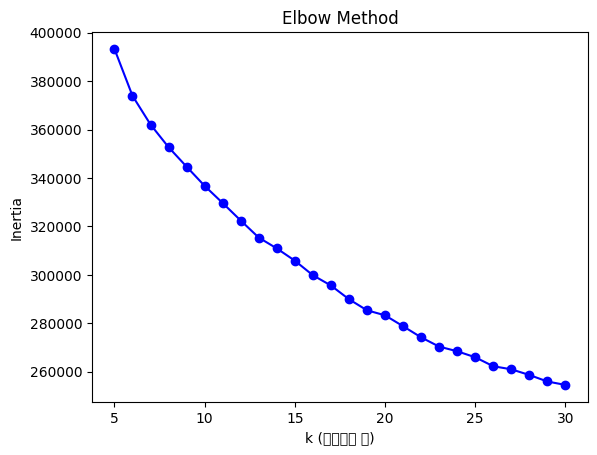

In [ ]:
import joblib

scaler = joblib.load('/content/drive/MyDrive/PosePick/good/good_features_scaler.pkl')
X_scaled = np.load('/content/drive/MyDrive/PosePick/good/good_train_scaled.npy')

find_optimal_k(X_scaled)

###### g.

📦 데이터를 불러오는 중...

🚀 [실행 중] Version A (Absolute Coords) 엘보우 메소드 계산 시작...


/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/

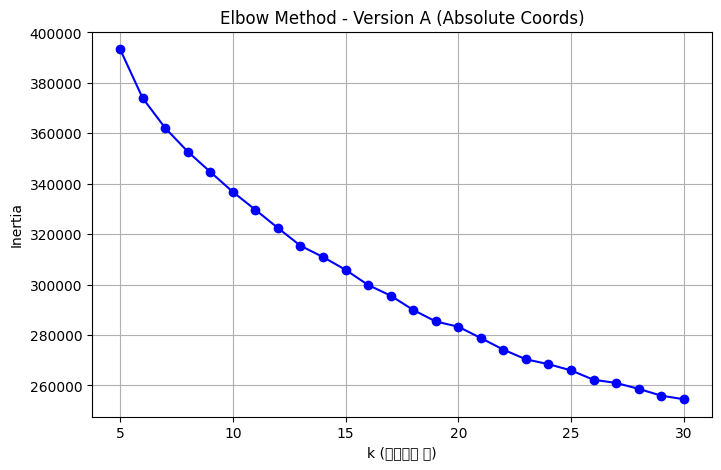

✅ [완료] Version A (Absolute Coords) 그래프가 'elbow_version_A.png' 파일로 저장되었습니다.

🚀 [실행 중] Version B (No Coords) 엘보우 메소드 계산 시작...


/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/

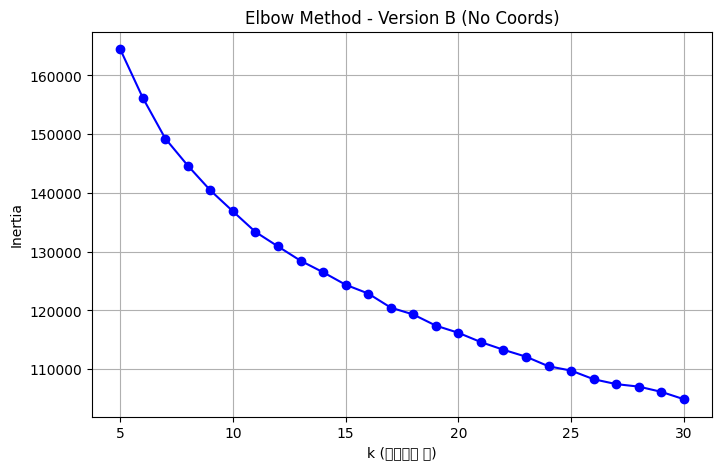

✅ [완료] Version B (No Coords) 그래프가 'elbow_version_B.png' 파일로 저장되었습니다.

🚀 [실행 중] Version C (Pelvis Normalized) 엘보우 메소드 계산 시작...


/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/tmp/ipykernel_1140/1556823293.py:49: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.savefig(save_filename)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/

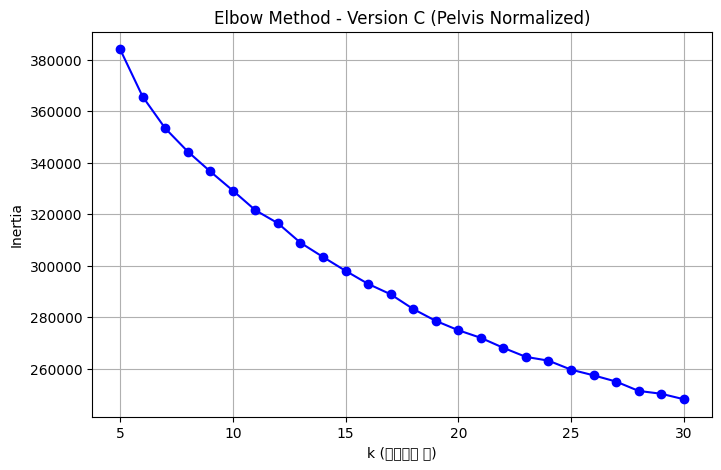

✅ [완료] Version C (Pelvis Normalized) 그래프가 'elbow_version_C.png' 파일로 저장되었습니다.

🎉 모든 버전의 엘보우 메소드 실험이 끝났습니다! 저장된 3개의 이미지를 비교해보세요.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 필수 함수 정의 (스케일러, 정규화, 엘보우)
# ==========================================

def fit_scaler(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return scaler, X_scaled

def normalize_by_pelvis(X_features):
    X_norm = X_features.copy()
    coords_3d = X_norm[:, :88]
    N = coords_3d.shape[0]
    joints = coords_3d.reshape(N, 22, 4)

    # 12, 13번 골반 관절 추출 후 중심점 계산
    left_hip = joints[:, 12, :3]
    right_hip = joints[:, 13, :3]
    mid_hip = (left_hip + right_hip) / 2.0

    # 상대 좌표 변환
    joints[:, :, :3] -= mid_hip[:, np.newaxis, :]
    X_norm[:, :88] = joints.reshape(N, 88)
    return X_norm

# 버그가 수정된 일반 KMeans 기반 엘보우 메소드 함수
def find_optimal_k(X_scaled, title_name, save_filename, k_range=range(5, 31)):
    inertias = []
    print(f"\n🚀 [실행 중] {title_name} 엘보우 메소드 계산 시작...")

    for k in k_range:
        # MiniBatchKMeans 대신 일반 KMeans 사용 + n_init 상향으로 그래프 평평하게 보정
        km = KMeans(n_clusters=k, random_state=42, n_init=15)
        km.fit(X_scaled)
        inertias.append(km.inertia_)

    # 그래프 시각화 및 저장
    plt.figure(figsize=(8, 5))
    plt.plot(list(k_range), inertias, 'bo-')
    plt.xlabel("k (클러스터 수)")
    plt.ylabel("Inertia")
    plt.title(f"Elbow Method - {title_name}")
    plt.grid(True)
    plt.savefig(save_filename)
    plt.show()
    print(f"✅ [완료] {title_name} 그래프가 '{save_filename}' 파일로 저장되었습니다.")


# ==========================================
# 2. 데이터 불러오기
# ==========================================
print("📦 데이터를 불러오는 중...")
data = np.load('/content/drive/MyDrive/PosePick/good/pose_final_dataset.npz')
X = np.concatenate([data['coords_3d_vis'], data['dist_3d'],
                    data['ratios'], data['angles'], data['symmetry']], axis=1)


# ==========================================
# 3. 버전별 데이터 생성 및 엘보우 메소드 실행
# ==========================================

# --- [버전 A] 절대좌표 포함 (원래 코드 상태) ---
_, X_version_A = fit_scaler(X)
find_optimal_k(X_version_A, "Version A (Absolute Coords)", "elbow_version_A.png")

# --- [버전 B] 좌표 피처 완전 제외 (63차원 순수 포즈 특징) ---
_, X_version_B = fit_scaler(X[:, 88:])
find_optimal_k(X_version_B, "Version B (No Coords)", "elbow_version_B.png")

# --- [버전 C] 골반 기준 정규화 완료 (상대좌표 변환) ---
X_normalized = normalize_by_pelvis(X)
_, X_version_C = fit_scaler(X_normalized)
find_optimal_k(X_version_C, "Version C (Pelvis Normalized)", "elbow_version_C.png")

print("\n🎉 모든 버전의 엘보우 메소드 실험이 끝났습니다! 저장된 3개의 이미지를 비교해보세요.")

#### 실루엣 스코어

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(10, 16):
    km = MiniBatchKMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=2000)
    print(f"k={k}: silhouette={score:.4f}")

k=10: silhouette=0.0731
k=11: silhouette=0.0755
k=12: silhouette=0.0630
k=13: silhouette=0.0750
k=14: silhouette=0.0653
k=15: silhouette=0.0755


###### .g

In [ ]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

def find_silhouette_peak(X_scaled, title_name, k_range=range(5, 21)):
    from sklearn.metrics import silhouette_score
    import matplotlib.pyplot as plt

    scores = []
    print(f"📊 {title_name} 실루엣 스코어 계산 중...")

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=15)
        labels = km.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        scores.append(score)

    plt.figure(figsize=(8, 4))
    plt.plot(list(k_range), scores, 'ro-')
    plt.xlabel("k (클러스터 수)")
    plt.ylabel("Silhouette Score")
    plt.title(f"Silhouette Method - {title_name}")
    plt.grid(True)
    # 파일명을 자동으로 만들어서 저장
    filename = f"silhouette_{title_name.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(filename)
    plt.show()
    print(f"✅ 저장 완료: {filename}\n")

# A, B, C 세 버전 모두 실루엣 스코어 비교하기
find_silhouette_peak(X_version_A, "Version A (Absolute Coords)", k_range=range(5, 21))
find_silhouette_peak(X_version_B, "Version B (No Coords)", k_range=range(5, 21))
find_silhouette_peak(X_version_C, "Version C (Pelvis Normalized)", k_range=range(5, 21))

NameError: name 'X_version_A' is not defined

### 본 학습

#### 함수

##### 저장/불러오기

In [ ]:
from sklearn.cluster import MiniBatchKMeans

def save_model(scaler, kmeans, representatives, path = '/content/drive/MyDrive/PosePick/good/models/kmeans/pose_kmeans_model.pkl'):
    with open(path, "wb") as f:
        pickle.dump({
            "scaler": scaler,
            "kmeans": kmeans,
            "representatives": representatives  # 추가
        }, f)
    print(f"모델 저장 완료: {path}")

def load_model(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data["scaler"], data["kmeans"], data["representatives"]

##### 학습 및 대표 이미지 저장

In [ ]:
import pickle

def train_kmeans(X_scaled, n_clusters=20, random_state=42):
    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        batch_size=1024,
        n_init=10,
        verbose=1
    )
    kmeans.fit(X_scaled)
    return kmeans

def find_representative_images(X_scaled, image_ids, kmeans):
    centers = kmeans.cluster_centers_
    representatives = {}
    for cluster_id in range(kmeans.n_clusters):
        mask = kmeans.labels_ == cluster_id
        cluster_indices = np.where(mask)[0]
        cluster_samples = X_scaled[cluster_indices]
        center = centers[cluster_id]
        dists = np.linalg.norm(cluster_samples - center, axis=1)
        nearest_idx = cluster_indices[dists.argmin()]
        representatives[cluster_id] = {
            "idx":            int(nearest_idx),
            "image_id":       image_ids[nearest_idx],
            "dist_to_center": float(dists.min())
        }
    return representatives

#### 학습 실행

In [ ]:
import os
import shutil
import pickle
from datetime import datetime
import numpy as np
import joblib
from sklearn.cluster import KMeans

# ==========================================
# 1. 핵심 함수 정의
# ==========================================

def train_kmeans(X, n_clusters, random_state=42):
    print(f"🚀 일반 KMeans로 학습 시작! (k={n_clusters})")
    # n_init을 15로 주어 초기화 노이즈를 방지하고 최적의 결과를 찾습니다.
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=15)
    kmeans.fit(X)
    return kmeans

def find_representative_images(X, image_ids, kmeans_model):
    # 각 클러스터의 중심점(centroid)과 가장 가까운 이미지를 대표로 선정
    representatives = {}
    centroids = kmeans_model.cluster_centers_
    labels = kmeans_model.labels_

    for k in range(kmeans_model.n_clusters):
        # 해당 클러스터에 속한 데이터들의 인덱스 찾기
        cluster_indices = np.where(labels == k)[0]
        if len(cluster_indices) == 0:
            continue

        # 중심점과 클러스터 내 데이터들 간의 거리 계산
        cluster_data = X[cluster_indices]
        distances = np.linalg.norm(cluster_data - centroids[k], axis=1)

        # 가장 거리가 짧은(중심에 가까운) 데이터의 인덱스 추출
        closest_idx_in_cluster = np.argmin(distances)
        original_idx = cluster_indices[closest_idx_in_cluster]

        # 대표 이미지 ID 저장
        representatives[k] = image_ids[original_idx]

    return representatives

def save_model(scaler, kmeans, representatives, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    joblib.dump({
        "scaler": scaler,
        "kmeans": kmeans,
        "representatives": representatives
    }, path)
    print(f"✅ 모델 저장 완료: {path}")

def load_model(path):
    data = joblib.load(path)
    return data["scaler"], data["kmeans"], data["representatives"]


# ==========================================
# 2. 메인 실행 (데이터 준비 & 학습 & 저장)
# ==========================================
print("📦 데이터를 불러오고 준비하는 중...")

# 데이터 및 스케일러 로드
X_scaled = np.load('/content/drive/MyDrive/PosePick/good/good_train_scaled.npy')
scaler   = joblib.load('/content/drive/MyDrive/PosePick/good/good_features_scaler.pkl')
image_ids = np.load('/content/drive/MyDrive/PosePick/good/pose_final_dataset.npz')['img_ids']

# 🚨 [필수] 절대좌표 노이즈 제거 (88번 인덱스부터 끝까지, 순수 포즈 63차원)
X_pure_pose = X_scaled[:, 88:]

MODEL_PATH = '/content/drive/MyDrive/PosePick/good/models/kmeans/pose_kmeans_model.pkl'
BACKUP_DIR = '/content/drive/MyDrive/PosePick/good/models/kmeans/'
os.makedirs(BACKUP_DIR, exist_ok=True)

# 모델 백업
if os.path.exists(MODEL_PATH):
    date_suffix = datetime.now().strftime("_%y%m%d_%H%M%S")
    backup_path = BACKUP_DIR + f'pose_kmeans_model{date_suffix}.pkl'
    shutil.copy(MODEL_PATH, backup_path)
    print(f"💾 기존 모델 백업 완료: {backup_path}")

# 🚨 최적의 K값 적용
OPTIMAL_K = 9

# 학습 및 대표 이미지 추출 (X_pure_pose 사용)
kmeans = train_kmeans(X_pure_pose, n_clusters=OPTIMAL_K, random_state=42)
representatives = find_representative_images(X_pure_pose, image_ids, kmeans)

# 모델 저장
save_model(scaler, kmeans, representatives, path=MODEL_PATH)

print(f"\n=== 🎉 진짜 완벽한 K-Means 학습 완료! ===")
print(f"📍 저장 경로:    {MODEL_PATH}")
print(f"🧩 클러스터 수:  {kmeans.n_clusters} (정상: 9)")
print(f"📉 inertia:      {kmeans.inertia_:.2f} (정상: 10만 대 수치)")
print(f"📏 학습 피처 수: {X_pure_pose.shape[1]} (정상: 63)")

📦 데이터를 불러오고 준비하는 중...
💾 기존 모델 백업 완료: /content/drive/MyDrive/PosePick/good/models/kmeans/pose_kmeans_model_260521_020010.pkl
🚀 일반 KMeans로 학습 시작! (k=9)
✅ 모델 저장 완료: /content/drive/MyDrive/PosePick/good/models/kmeans/pose_kmeans_model.pkl

=== 🎉 진짜 완벽한 K-Means 학습 완료! ===
📍 저장 경로:    /content/drive/MyDrive/PosePick/good/models/kmeans/pose_kmeans_model.pkl
🧩 클러스터 수:  9 (정상: 9)
📉 inertia:      140432.08 (정상: 10만 대 수치)
📏 학습 피처 수: 63 (정상: 63)


In [ ]:
import numpy as np
import joblib
import requests
from IPython.display import display, Image

# ==========================================
# 1. 모델 로드
# ==========================================
MODEL_PATH = '/content/drive/MyDrive/PosePick/good/models/kmeans/pose_kmeans_model.pkl'

print("📦 모델을 불러오는 중...")
data = joblib.load(MODEL_PATH)
kmeans = data["kmeans"]
representatives = data["representatives"]
labels = kmeans.labels_


# ==========================================
# 2. 클러스터별 샘플 수 통계 및 텍스트 바 차트
# ==========================================
counts = np.bincount(labels)

print(f"\n=== 📊 클러스터별 샘플 수 ===")
for i, count in enumerate(counts):
    bar = "█" * (count * 30 // counts.max())
    print(f"  클러스터 {i:>2}: {count:>5}개  {bar}")

print(f"\n  최대: {counts.max():>5}개 (클러스터 {counts.argmax()})")
print(f"  최소: {counts.min():>5}개 (클러스터 {counts.argmin()})")
print(f"  평균: {counts.mean():>7.1f}개")


# ==========================================
# 3. 클러스터별 대표 이미지 시각화 (URL 방식)
# ==========================================
print(f"\n=== 🖼️ 클러스터별 대표 이미지 ===")

for cluster_id, rep in representatives.items():
    # 데이터 구조 안전망: dict 형태면 image_id를 꺼내고, 아니면 rep(정수/문자열) 그대로 사용
    img_id = rep['image_id'] if isinstance(rep, dict) else rep

    # 거리 정보도 저장되어 있다면 안전하게 가져오기 (없으면 0.0 처리)
    dist = rep['dist_to_center'] if isinstance(rep, dict) and 'dist_to_center' in rep else 0.0000

    try:
        # 사용자 정의 함수로 URL 가져오기
        image_url = get_image_url(img_id)

        # 출력 텍스트 포맷 (거리 정보 유무에 따라 다르게)
        if isinstance(rep, dict) and 'dist_to_center' in rep:
            print(f"\n▶ 클러스터 {cluster_id:>2} (dist={dist:.4f}): {image_url}")
        else:
            print(f"\n▶ 클러스터 {cluster_id:>2} (ID={img_id}): {image_url}")

        # requests로 이미지 불러와서 출력
        response = requests.get(image_url)
        display(Image(data=response.content, width=200))

    except Exception as e:
        print(f"  ⚠️ 클러스터 {cluster_id:>2} 로드 실패 ({e})")

📦 모델을 불러오는 중...

=== 📊 클러스터별 샘플 수 ===
  클러스터  0:   233개  █████████
  클러스터  1:   764개  ██████████████████████████████
  클러스터  2:   262개  ██████████
  클러스터  3:   626개  ████████████████████████
  클러스터  4:   259개  ██████████
  클러스터  5:   432개  ████████████████
  클러스터  6:   693개  ███████████████████████████
  클러스터  7:    69개  ██
  클러스터  8:   589개  ███████████████████████

  최대:   764개 (클러스터 1)
  최소:    69개 (클러스터 7)
  평균:   436.3개

=== 🖼️ 클러스터별 대표 이미지 ===

▶ 클러스터  0 (ID=1442): https://firebasestorage.googleapis.com/v0/b/<YOUR_FIREBASE_BUCKET>/o/selected%2F1442.jpg?alt=media



▶ 클러스터  1 (ID=3593): https://firebasestorage.googleapis.com/v0/b/<YOUR_FIREBASE_BUCKET>/o/selected%2F3593.jpg?alt=media



▶ 클러스터  2 (ID=816): https://firebasestorage.googleapis.com/v0/b/<YOUR_FIREBASE_BUCKET>/o/selected%2F816.jpg?alt=media



▶ 클러스터  3 (ID=3406): https://firebasestorage.googleapis.com/v0/b/<YOUR_FIREBASE_BUCKET>/o/selected%2F3406.jpg?alt=media



▶ 클러스터  4 (ID=1906): https://firebasestorage.googleapis.com/v0/b/<YOUR_FIREBASE_BUCKET>/o/selected%2F1906.jpg?alt=media



▶ 클러스터  5 (ID=2339): https://firebasestorage.googleapis.com/v0/b/<YOUR_FIREBASE_BUCKET>/o/selected%2F2339.jpg?alt=media



▶ 클러스터  6 (ID=617): https://firebasestorage.googleapis.com/v0/b/<YOUR_FIREBASE_BUCKET>/o/selected%2F617.jpg?alt=media



▶ 클러스터  7 (ID=1036): https://firebasestorage.googleapis.com/v0/b/<YOUR_FIREBASE_BUCKET>/o/selected%2F1036.jpg?alt=media



▶ 클러스터  8 (ID=1803): https://firebasestorage.googleapis.com/v0/b/<YOUR_FIREBASE_BUCKET>/o/selected%2F1803.jpg?alt=media


[이미지 출력 제거: 원본 사진(저작권·개인정보) 포함]


In [ ]:
import numpy as np
import joblib
import requests
import base64
from IPython.display import display, HTML

# ==========================================
# 1. 데이터 및 기존 모델 로드
# ==========================================
print("📦 데이터와 모델을 불러오는 중...")
X_scaled = np.load('/content/drive/MyDrive/PosePick/good/good_train_scaled.npy')
image_ids = np.load('/content/drive/MyDrive/PosePick/good/pose_final_dataset.npz')['img_ids']

# 🚨 모델이 학습했던 '순수 포즈 피처'를 다시 만들어줍니다.
X_pure_pose = X_scaled[:, 88:]

MODEL_PATH = '/content/drive/MyDrive/PosePick/good/models/kmeans/pose_kmeans_model.pkl'
data = joblib.load(MODEL_PATH)
kmeans = data["kmeans"]


# ==========================================
# 2. 중심에서 가장 가까운 상위 10장 추출 함수
# ==========================================
def get_top_n_representatives(X, image_ids, kmeans_model, n=10):
    top_n_reps = {}
    centroids = kmeans_model.cluster_centers_
    labels = kmeans_model.labels_

    for k in range(kmeans_model.n_clusters):
        cluster_indices = np.where(labels == k)[0]
        if len(cluster_indices) == 0:
            continue

        # 클러스터 내 데이터들과 중심점 간의 거리 계산
        cluster_data = X[cluster_indices]
        distances = np.linalg.norm(cluster_data - centroids[k], axis=1)

        # 거리가 가까운 순으로 정렬하여 상위 n개의 인덱스 추출
        closest_indices = np.argsort(distances)[:n]
        original_indices = cluster_indices[closest_indices]

        # 딕셔너리 리스트 형태로 정보 저장
        top_n_reps[k] = [
            {"image_id": image_ids[orig_idx], "dist_to_center": distances[closest_idx]}
            for orig_idx, closest_idx in zip(original_indices, closest_indices)
        ]
    return top_n_reps

# 💡 n=10으로 수정
print("🔍 클러스터별 중심에 가장 가까운 10장을 찾는 중...")
top_10_representatives = get_top_n_representatives(X_pure_pose, image_ids, kmeans, n=10)


# ==========================================
# 3. HTML 기반 가로 갤러리 렌더링
# ==========================================
# 💡 텍스트 수정
print("\n=== 🖼️ 클러스터별 대표 이미지 (Top 10 갤러리) ===")

# HTML 뼈대 생성
html_content = "<div style='background-color: #f8f9fa; padding: 20px; border-radius: 10px;'>"

# 💡 순회할 변수명 변경
for cluster_id, reps in top_10_representatives.items():
    html_content += f"<h3 style='margin-bottom: 10px; color: #333;'>▶ 클러스터 {cluster_id}</h3>"
    html_content += "<div style='display: flex; flex-wrap: wrap; gap: 15px; margin-bottom: 30px;'>"

    for rep in reps:
        img_id = rep['image_id']
        dist = rep['dist_to_center']

        try:
            # 1) 기존 방식대로 URL 가져오기
            img_url = get_image_url(img_id)

            # 2) requests로 이미지 데이터 다운로드
            response = requests.get(img_url)

            # 3) 코랩 HTML에 직접 띄울 수 있도록 Base64 인코딩 (보안/네트워크 이슈 방지)
            b64_img = base64.b64encode(response.content).decode('utf-8')

            # 4) 가로 카드 UI로 추가
            html_content += f"""
            <div style='text-align: center; background: white; padding: 10px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
                <img src='data:image/jpeg;base64,{b64_img}' style='width: 150px; height: 150px; object-fit: contain; margin-bottom: 8px;'/>
                <div style='font-size: 13px; color: #555; font-family: monospace;'>
                    ID: {img_id}<br>dist: <b>{dist:.4f}</b>
                </div>
            </div>
            """
        except Exception as e:
            html_content += f"<div style='width: 150px; padding: 10px; color: red; font-size: 12px; border: 1px solid red;'>⚠️ {img_id} 로드 실패</div>"

    html_content += "</div><hr style='border: 0; border-top: 2px solid #ddd; margin-bottom: 30px;'/>"

html_content += "</div>"

# 최종 HTML 출력
display(HTML(html_content))

📦 데이터와 모델을 불러오는 중...
🔍 클러스터별 중심에 가장 가까운 10장을 찾는 중...

=== 🖼️ 클러스터별 대표 이미지 (Top 10 갤러리) ===


[이미지 출력 제거: 원본 사진(저작권·개인정보) 포함]


In [ ]:
import numpy as np
import requests
import base64
from IPython.display import display, HTML
from sklearn.cluster import KMeans

# ==========================================
# 1. 갤러리 렌더링 함수 정의 (HTML + Base64)
# ==========================================
def render_cluster_gallery(X_data, image_ids, kmeans_model, version_name, n=5):
    print(f"\n🔍 [{version_name}] 클러스터별 중심에 가장 가까운 {n}장을 찾는 중...")

    # 상위 N장 추출
    top_n_reps = get_top_n_representatives(X_data, image_ids, kmeans_model, n=n)

    # HTML 뼈대 생성
    html_content = f"<div style='background-color: #f8f9fa; padding: 20px; border-radius: 10px; margin-bottom: 50px;'>"
    html_content += f"<h2 style='text-align: center; color: #2c3e50; margin-bottom: 20px;'>{version_name} 결과 시각화</h2>"

    for cluster_id, reps in top_n_reps.items():
        html_content += f"<h3 style='margin-bottom: 10px; color: #333;'>▶ 클러스터 {cluster_id}</h3>"
        html_content += "<div style='display: flex; flex-wrap: wrap; gap: 15px; margin-bottom: 30px;'>"

        for rep in reps:
            img_id = rep['image_id']
            dist = rep['dist_to_center']

            try:
                # 1) 기존 방식대로 URL 가져오기
                img_url = get_image_url(img_id)

                # 2) requests로 이미지 데이터 다운로드
                response = requests.get(img_url, timeout=5)

                # 3) 코랩 HTML에 직접 띄울 수 있도록 Base64 인코딩
                b64_img = base64.b64encode(response.content).decode('utf-8')

                # 4) 가로 카드 UI로 추가
                html_content += f"""
                <div style='text-align: center; background: white; padding: 10px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
                    <img src='data:image/jpeg;base64,{b64_img}' style='width: 150px; height: 150px; object-fit: contain; margin-bottom: 8px;'/>
                    <div style='font-size: 13px; color: #555; font-family: monospace;'>
                        ID: {img_id}<br>dist: <b>{dist:.4f}</b>
                    </div>
                </div>
                """
            except Exception as e:
                html_content += f"<div style='width: 150px; height: 150px; padding: 10px; color: red; font-size: 12px; border: 1px solid red; display: flex; align-items: center; justify-content: center;'>⚠️ {img_id} 로드 실패</div>"

        html_content += "</div><hr style='border: 0; border-top: 2px solid #ddd; margin-bottom: 30px;'/>"

    html_content += "</div>"

    # 최종 HTML 출력
    display(HTML(html_content))


# ==========================================
# 2. Version A / Version C 모델 학습 및 시각화
# ==========================================
# (주의: X_version_A, X_version_C 변수가 이미 선언되어 있어야 합니다)

# --- Version A (원본 151차원) ---
print("▶ Version A K-Means 학습 중...")
kmeans_a = KMeans(n_clusters=9, random_state=42, n_init=15)
kmeans_a.fit(X_version_A)
render_cluster_gallery(X_version_A, image_ids, kmeans_a, "Version A (Absolute Coords)", n=10)

# --- Version C (골반 정규화) ---
print("▶ Version C K-Means 학습 중...")
kmeans_c = KMeans(n_clusters=9, random_state=42, n_init=15)
kmeans_c.fit(X_version_C)
render_cluster_gallery(X_version_C, image_ids, kmeans_c, "Version C (Pelvis Normalized)", n=10)

▶ Version A K-Means 학습 중...

🔍 [Version A (Absolute Coords)] 클러스터별 중심에 가장 가까운 10장을 찾는 중...


▶ Version C K-Means 학습 중...

🔍 [Version C (Pelvis Normalized)] 클러스터별 중심에 가장 가까운 10장을 찾는 중...


[이미지 출력 제거: 원본 사진(저작권·개인정보) 포함]


## KNN 학습

### 학습 실행

In [ ]:
import os
import shutil
from datetime import datetime
import numpy as np
import joblib
from sklearn.neighbors import NearestNeighbors

# ==========================================
# 1. 필수 함수 정의
# ==========================================
def train_knn(X, n_neighbors=10):
    print("🚀 KNN (NearestNeighbors) '지도 암기' 시작...")
    knn_cosine = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine', n_jobs=-1)
    knn_cosine.fit(X)
    return knn_cosine

def save_knn_model(scaler, knn, image_ids, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    joblib.dump({
        "scaler": scaler,
        "knn": knn,
        "image_ids": image_ids  # 나중에 인덱스로 원본 사진 ID를 찾기 위해 반드시 함께 저장!
    }, path)
    print(f"✅ KNN 모델 저장 완료: {path}")

# ==========================================
# 2. 데이터 로드 및 🌟순수 포즈 피처 추출🌟
# ==========================================
print("📦 데이터를 준비하는 중...")
X_scaled = np.load('/content/drive/MyDrive/PosePick/good/good_train_scaled.npy')
scaler   = joblib.load('/content/drive/MyDrive/PosePick/good/good_features_scaler.pkl')
image_ids = np.load('/content/drive/MyDrive/PosePick/good/pose_final_dataset.npz')['img_ids']

# 🚨 [가장 중요!] K-Means 때와 똑같이 위치 노이즈를 덜어낸 63차원(Version B)만 사용합니다.
X_pure_pose = X_scaled[:, 88:]


# ==========================================
# 3. 모델 백업 및 학습
# ==========================================
KNN_MODEL_PATH = '/content/drive/MyDrive/PosePick/good/models/knn/pose_knn_model.pkl'
KNN_BACKUP_DIR = '/content/drive/MyDrive/PosePick/good/models/knn/'
os.makedirs(KNN_BACKUP_DIR, exist_ok=True)

# 기존 모델 백업
if os.path.exists(KNN_MODEL_PATH):
    date_suffix = datetime.now().strftime("_%y%m%d_%H%M%S")
    backup_path = KNN_BACKUP_DIR + f'pose_knn_model{date_suffix}.pkl'
    shutil.copy(KNN_MODEL_PATH, backup_path)
    print(f"💾 기존 모델 백업 완료: {backup_path}")

# KNN 학습 (n_neighbors는 본인 외에 나와 비슷한 5명을 찾기 위해 6으로 세팅하거나, 5로 둡니다)
# (보통 쿼리 이미지 자신까지 포함해 1순위로 나오므로, 실사용 시 6개를 뽑아 자기 자신을 제외합니다)
knn = train_knn(X_pure_pose, n_neighbors=5)
n_samples = X_pure_pose.shape[0]

# 모델, 스케일러, 이미지ID 매핑 테이블까지 한 번에 저장
save_knn_model(scaler, knn, image_ids, path=KNN_MODEL_PATH)


# ==========================================
# 4. 결과 출력
# ==========================================
print(f"\n=== 🎉 완벽한 KNN 모델 학습 완료 ===")
print(f"📍 저장 경로:    {KNN_MODEL_PATH}")
print(f"👥 n_neighbors:  {knn.n_neighbors}")
print(f"📏 metric:       {knn.metric}")
print(f"📊 학습 샘플 수: {n_samples}개")
print(f"✨ 학습 피처 수: {X_pure_pose.shape[1]}개 (순수 포즈 피처만 적용됨!)")

📦 데이터를 준비하는 중...
💾 기존 모델 백업 완료: /content/drive/MyDrive/PosePick/good/models/knn/pose_knn_model_260521_001608.pkl
🚀 KNN (NearestNeighbors) '지도 암기' 시작...
✅ KNN 모델 저장 완료: /content/drive/MyDrive/PosePick/good/models/knn/pose_knn_model.pkl

=== 🎉 완벽한 KNN 모델 학습 완료 ===
📍 저장 경로:    /content/drive/MyDrive/PosePick/good/models/knn/pose_knn_model.pkl
👥 n_neighbors:  5
📏 metric:       cosine
📊 학습 샘플 수: 3927개
✨ 학습 피처 수: 63개 (순수 포즈 피처만 적용됨!)


In [ ]:
import numpy as np
import joblib
import requests
import base64
import random  # 💡 랜덤 추출을 위한 모듈 추가
from IPython.display import display, HTML

# ==========================================
# 1. 새롭게 학습된 코사인 KNN 모델 로드
# ==========================================
MODEL_PATH = '/content/drive/MyDrive/PosePick/good/models/knn/pose_knn_model.pkl'
data = joblib.load(MODEL_PATH)

knn_cosine = data["knn"]
# 모델과 함께 묶어서 저장했던 이미지 ID 리스트를 꺼냅니다.
saved_image_ids = data["image_ids"]

# ==========================================
# 2. 검색 테스트 세팅 (🎲 랜덤 추출)
# ==========================================
# 💡 전체 데이터 개수 범위 내에서 랜덤으로 인덱스 하나를 뽑습니다.
target_idx = random.randint(0, len(saved_image_ids) - 1)

# 순수 포즈 피처(63차원)에서 타겟 데이터를 추출합니다.
# (1, 63) 형태의 2차원 배열을 유지하기 위해 슬라이싱을 사용합니다.
target_feature = X_pure_pose[target_idx:target_idx+1]

# 코사인 KNN으로 상위 5개 추출 (1위는 자기 자신)
distances, indices = knn_cosine.kneighbors(target_feature, n_neighbors=5)

print(f"\n=== 🎲 [Cosine KNN] 랜덤 타겟 이미지 ID: {saved_image_ids[target_idx]} (인덱스: {target_idx}) 의 유사 포즈 Top 5 ===")

# ==========================================
# 3. HTML 가로 갤러리 렌더링
# ==========================================
html_content = "<div style='display: flex; flex-wrap: wrap; gap: 15px; margin-top: 10px;'>"

for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    img_id = saved_image_ids[idx]

    try:
        # 기존 방식대로 URL 가져오기
        img_url = get_image_url(img_id)

        response = requests.get(img_url, timeout=5)
        b64_img = base64.b64encode(response.content).decode('utf-8')

        # 1위(타겟 원본)는 눈에 띄게 연두색으로 하이라이트 처리
        bg_color = "#e8f5e9" if rank == 0 else "white"
        title = "👑 쿼리 이미지" if rank == 0 else f"{rank+1}위"

        html_content += f"""
        <div style='text-align: center; background: {bg_color}; padding: 10px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); border: 1px solid #ddd;'>
            <div style='font-weight: bold; margin-bottom: 8px; color: #2e7d32;'>{title}</div>
            <img src='data:image/jpeg;base64,{b64_img}' style='width: 150px; height: 150px; object-fit: contain; margin-bottom: 8px;'/>
            <div style='font-size: 13px; color: #555; font-family: monospace; line-height: 1.4;'>
                ID: {img_id}<br>dist: <b>{dist:.4f}</b>
            </div>
        </div>
        """
    except Exception as e:
        html_content += f"<div style='width: 150px; height: 150px; padding: 10px; color: red; border: 1px solid red; display: flex; align-items: center; justify-content: center;'>⚠️ {img_id} 로드 실패</div>"

html_content += "</div>"
display(HTML(html_content))


=== 🎲 [Cosine KNN] 랜덤 타겟 이미지 ID: 3997 (인덱스: 2958) 의 유사 포즈 Top 5 ===


In [ ]:
import numpy as np
import random
import requests
import base64
from IPython.display import display, HTML

# 💡 랜덤으로 타겟 인덱스 하나 뽑기 (원하는 번호가 있다면 직접 입력해도 됩니다)
target_idx = random.randint(0, len(X_pure_pose) - 1)
target_feature = X_pure_pose[target_idx:target_idx+1]
target_img_id = saved_image_ids[target_idx]

print(f"🎲 랜덤 타겟 이미지 ID: {target_img_id} (인덱스: {target_idx})")

# ==========================================
# 1. KNN 결과 추출 (타겟과 가장 비슷한 Top 5)
# ==========================================
knn_distances, knn_indices = knn_cosine.kneighbors(target_feature, n_neighbors=5)
knn_results = list(zip(knn_distances[0], knn_indices[0]))

# ==========================================
# 2. K-Means 결과 추출 (타겟이 속한 클러스터의 중심점 기준 Top 5)
# ==========================================
# 타겟 이미지가 속한 클러스터(방 번호) 확인
target_cluster = kmeans.labels_[target_idx]

# 해당 클러스터에 속한 모든 데이터 찾기
cluster_indices = np.where(kmeans.labels_ == target_cluster)[0]
cluster_center = kmeans.cluster_centers_[target_cluster]

# 클러스터 중심점과 클러스터 내 데이터 간의 유클리디안 거리 계산
center_dists = np.linalg.norm(X_pure_pose[cluster_indices] - cluster_center, axis=1)

# 중심에서 가장 가까운 5장 추출
closest_idx_in_cluster = np.argsort(center_dists)[:5]
kmeans_results = [(center_dists[i], cluster_indices[i]) for i in closest_idx_in_cluster]

# ==========================================
# 3. HTML 갤러리 렌더링 함수
# ==========================================
def create_gallery_html(title, results, is_knn=False):
    html = f"<div style='background-color: #f8f9fa; padding: 20px; border-radius: 10px; margin-bottom: 30px;'>"
    html += f"<h3 style='margin-bottom: 15px; color: #333;'>{title}</h3>"
    html += "<div style='display: flex; flex-wrap: wrap; gap: 15px;'>"

    for rank, (dist, idx) in enumerate(results):
        img_id = saved_image_ids[idx]

        try:
            img_url = get_image_url(img_id)
            response = requests.get(img_url, timeout=5)
            b64_img = base64.b64encode(response.content).decode('utf-8')

            # 타겟 이미지 본인인 경우 하이라이트
            is_target = (img_id == target_img_id)
            bg_color = "#e8f5e9" if is_target else "white"
            border_color = "#4caf50" if is_target else "#ddd"

            badge = ""
            if is_knn and rank == 0:
                badge = "👑 쿼리 이미지"
            elif is_target:
                badge = "✨ 타겟 본인"
            else:
                badge = f"{rank+1}위"

            html += f"""
            <div style='text-align: center; background: {bg_color}; padding: 10px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); border: 2px solid {border_color};'>
                <div style='font-weight: bold; margin-bottom: 8px; color: #2e7d32;'>{badge}</div>
                <img src='data:image/jpeg;base64,{b64_img}' style='width: 150px; height: 150px; object-fit: contain; margin-bottom: 8px;'/>
                <div style='font-size: 13px; color: #555; font-family: monospace; line-height: 1.4;'>
                    ID: {img_id}<br>dist: <b>{dist:.4f}</b>
                </div>
            </div>
            """
        except Exception as e:
            html += f"<div style='width: 150px; height: 150px; padding: 10px; color: red; border: 1px solid red; display: flex; align-items: center; justify-content: center;'>⚠️ {img_id} 로드 실패</div>"

    html += "</div></div>"
    return html

# ==========================================
# 4. 최종 출력
# ==========================================
final_html = create_gallery_html(f"🔍 [KNN] '{target_img_id}'와 가장 비슷한 포즈 Top 5", knn_results, is_knn=True)
final_html += create_gallery_html(f"🏢 [K-Means] 타겟이 속한 '클러스터 {target_cluster}'의 핵심 대표 포즈 Top 5", kmeans_results, is_knn=False)

display(HTML(final_html))

🎲 랜덤 타겟 이미지 ID: 1662 (인덱스: 2233)


[이미지 출력 제거: 원본 사진(저작권·개인정보) 포함]


### 평가

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

# ==========================================
# 1. K-Means 추론 함수 (b 계산 로직)
# ==========================================
def infer_kmeans(X_input_scaled, kmeans_model):
    results = []
    for i in range(len(X_input_scaled)):
        query_scaled = X_input_scaled[i].reshape(1, -1)
        predicted_cluster = kmeans_model.predict(query_scaled)[0]
        cluster_center = kmeans_model.cluster_centers_[predicted_cluster]

        # 코사인 거리 측정 후 0.3 가중치로 스케일 조정
        feature_diff = float(cosine(X_input_scaled[i], cluster_center)) * 0.3
        score = round((1 / (1 + feature_diff)) * 100, 2)

        results.append({
            "predicted_cluster": predicted_cluster,
            "center_diff": round(feature_diff, 4),
            "score": score
        })
    return results

# ==========================================
# 2. KNN 추론 함수 (a 계산 로직)
# ==========================================
def infer_knn(X_input_scaled, X_train_scaled, knn, image_ids):
    results = []

    # 배열 전체를 한 번에 연산 (Vectorization)
    distances_batch, indices_batch = knn.kneighbors(X_input_scaled)

    for i in range(len(X_input_scaled)):
        distances = distances_batch[i]
        indices = indices_batch[i]

        top5 = []
        for rank, (dist, idx) in enumerate(zip(distances, indices)):
            feature_diff = float(dist)
            score = round((1 / (1 + feature_diff)) * 100, 2)

            top5.append({
                "rank":         rank + 1,
                "image_id":     int(image_ids[idx]),
                "dist":         round(feature_diff, 4),
                "score":        score,
            })

        # Top 1 결과만 저장
        results.append({
            "image_id": top5[0]["image_id"],
            "score":    top5[0]["score"],
        })
    return results

# ==========================================
# 3. 메인 검증 파이프라인 (🔥 핵심: 데이터 완벽 분리)
# ==========================================

# 1) 전체 데이터를 8:2로 쪼갭니다.
X_train, X_test, ids_train, ids_test = train_test_split(
    X_pure_pose, saved_image_ids,
    test_size=0.2,       # 20%를 테스트(가상 유저)용으로 격리
    random_state=42      # 매번 결과가 바뀌지 않도록 시드 고정
)

print(f"📦 [격리 완료] K-Means/KNN이 정답으로 쓸 레퍼런스 데이터: {len(X_train)}장")
print(f"🕵️‍♂️ [테스트 시작] 처음 보는 미지의 유저 데이터: {len(X_test)}장\n")

# 2) 훈련용 데이터(X_train)만 보고 모델들을 새로 학습시킵니다.
kmeans_clean = KMeans(n_clusters=9, random_state=42).fit(X_train)
knn_clean = NearestNeighbors(n_neighbors=5, metric='cosine').fit(X_train)

# 3) 테스트용 데이터(X_test)로 추론을 실행합니다.
# 주의: KNN이 정답을 찾을 때 ids_train(학습용 ID 목록)에서 찾아오도록 연결합니다.
knn_results = infer_knn(X_test, X_train, knn_clean, ids_train)
kmeans_results = infer_kmeans(X_test, kmeans_clean)

# 리스트 생성
a_list, b_list = [], []
for i in range(len(X_test)):
    a_list.append(knn_results[i]["score"])
    b_list.append(kmeans_results[i]["score"])

df = pd.DataFrame({
    'Score_KNN (a)': a_list,
    'Score_KMeans (b)': b_list,
    'Difference (b-a)': np.array(b_list) - np.array(a_list)
})

# ==========================================
# 4. 알고리즘 오차(Variance) 분포 시각화
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# [그래프 1] a vs b 산점도
sns.scatterplot(x='Score_KNN (a)', y='Score_KMeans (b)', data=df, ax=ax1, alpha=0.6, color='#2b5b84')
min_val = min(df['Score_KNN (a)'].min(), df['Score_KMeans (b)'].min())
max_val = max(df['Score_KNN (a)'].max(), df['Score_KMeans (b)'].max())
ax1.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='y=x (Perfect Match)')

ax1.set_title("Algorithm Consistency: KNN vs K-Means Score", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("KNN Score (a) -> High Detail Matching")
ax1.set_ylabel("K-Means Score (b) -> General Template Matching")
ax1.legend()
ax1.grid(True, alpha=0.3)

# [그래프 2] (b-a) 차이값 히스토그램
sns.histplot(df['Difference (b-a)'], kde=True, bins=30, ax=ax2, color='#d9534f')
ax2.axvline(0, color='black', linestyle='--', linewidth=2)
ax2.set_title("Difference Distribution (b - a)", fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("Score Diff (Negative: KNN higher, Positive: K-Means higher)")
ax2.set_ylabel("Frequency")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 5. 엔지니어링 리포트 출력
# ==========================================
mean_diff = df['Difference (b-a)'].mean()
std_diff = df['Difference (b-a)'].std()

print("=== 📊 포즈 평가 알고리즘 최종 디버깅 리포트 ===")
print(f"✔ 두 점수의 평균 차이 (Bias) : {mean_diff:.4f} (0에 가까울수록 밸런스가 좋음)")
print(f"✔ 두 점수의 표준편차 (Spread) : {std_diff:.4f} (적절히 커야 변칙 포즈를 분별함)")

if mean_diff < -5.0:
    print("\n⚠️ 경고: K-Means 점수(b)가 전반적으로 너무 낮습니다.")
    print("   -> 해결책: 'infer_kmeans' 함수의 feature_diff에 곱해진 0.3을 0.2 나 0.15로 더 줄여보세요.")
elif mean_diff > 5.0:
    print("\n⚠️ 경고: KNN 점수(a)가 전반적으로 너무 낮습니다.")
    print("   -> 해결책: 'infer_kmeans' 함수의 feature_diff에 곱해진 0.3을 0.4 나 0.5로 키워보세요.")
else:
    print("\n✅ 훌륭합니다! 데이터 누수 없이도 KNN과 K-Means 간의 채점 스케일이 완벽하게 균형을 이루고 있습니다.")

NameError: name 'X_pure_pose' is not defined

📦 [격리 완료] K-Means/KNN이 정답으로 쓸 레퍼런스 데이터: 3141장
🕵️‍♂️ [테스트 시작] 처음 보는 미지의 유저 데이터: 786장



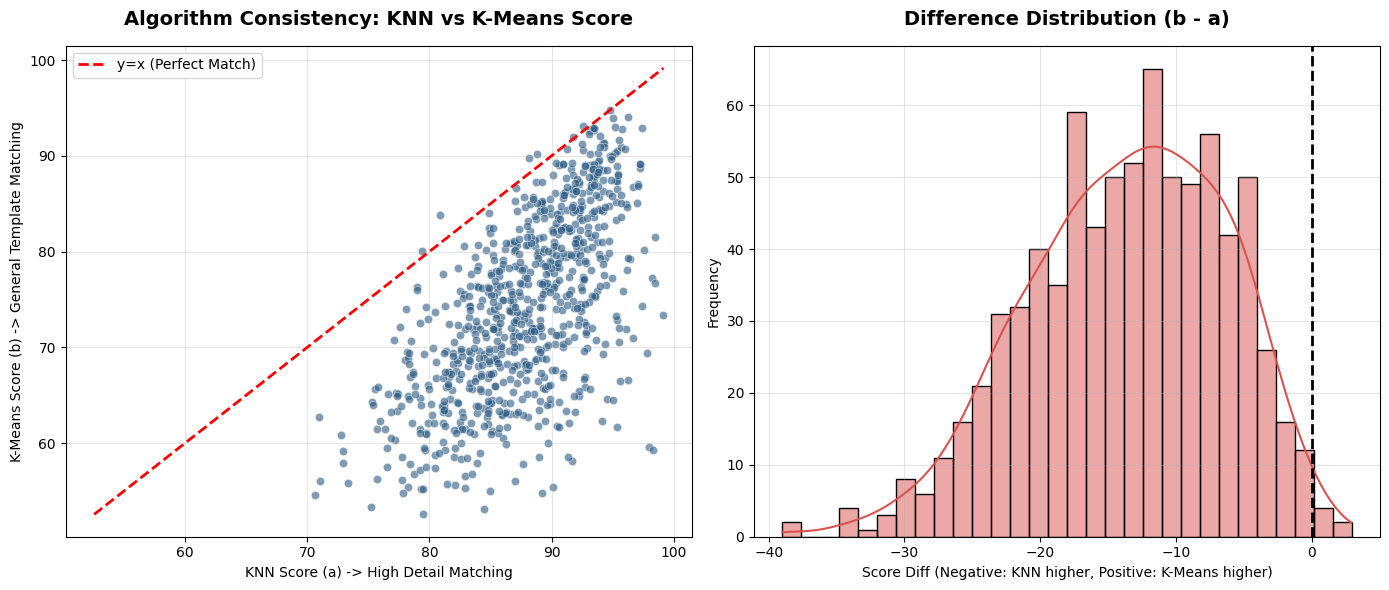

=== 📊 포즈 평가 알고리즘 최종 디버깅 리포트 ===
✔ 두 점수의 평균 차이 (Bias) : -13.6245 (0에 가까울수록 밸런스가 좋음)
✔ 두 점수의 표준편차 (Spread) : 7.2538 (적절히 커야 변칙 포즈를 분별함)

⚠️ 경고: K-Means 점수(b)가 전반적으로 너무 낮습니다.
   -> 해결책: 'infer_kmeans' 함수의 feature_diff에 곱해진 0.3을 0.2 나 0.15로 더 줄여보세요.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

# ==========================================
# 1. K-Means 추론 함수 (b 계산 로직)
# ==========================================
def infer_kmeans(X_input_scaled, kmeans_model):
    results = []
    for i in range(len(X_input_scaled)):
        query_scaled = X_input_scaled[i].reshape(1, -1)
        predicted_cluster = kmeans_model.predict(query_scaled)[0]
        cluster_center = kmeans_model.cluster_centers_[predicted_cluster]

        # 코사인 거리 측정 후 0.3 가중치로 스케일 조정
        feature_diff = float(cosine(X_input_scaled[i], cluster_center))
        score = round((1 / (1 + feature_diff)) * 100, 2)

        results.append({
            "predicted_cluster": predicted_cluster,
            "center_diff": round(feature_diff, 4),
            "score": score
        })
    return results

# ==========================================
# 2. KNN 추론 함수 (a 계산 로직)
# ==========================================
def infer_knn(X_input_scaled, X_train_scaled, knn, image_ids):
    results = []

    # 배열 전체를 한 번에 연산 (Vectorization)
    distances_batch, indices_batch = knn.kneighbors(X_input_scaled)

    for i in range(len(X_input_scaled)):
        distances = distances_batch[i]
        indices = indices_batch[i]

        top5 = []
        for rank, (dist, idx) in enumerate(zip(distances, indices)):
            feature_diff = float(dist)
            score = round((1 / (1 + feature_diff)) * 100, 2)

            top5.append({
                "rank":         rank + 1,
                "image_id":     int(image_ids[idx]),
                "dist":         round(feature_diff, 4),
                "score":        score,
            })

        # Top 1 결과만 저장
        results.append({
            "image_id": top5[0]["image_id"],
            "score":    top5[0]["score"],
        })
    return results

# ==========================================
# 3. 메인 검증 파이프라인 (🔥 핵심: 데이터 완벽 분리)
# ==========================================

# 1) 전체 데이터를 8:2로 쪼갭니다.
X_train, X_test, ids_train, ids_test = train_test_split(
    X_pure_pose, saved_image_ids,
    test_size=0.2,       # 20%를 테스트(가상 유저)용으로 격리
    random_state=42      # 매번 결과가 바뀌지 않도록 시드 고정
)

print(f"📦 [격리 완료] K-Means/KNN이 정답으로 쓸 레퍼런스 데이터: {len(X_train)}장")
print(f"🕵️‍♂️ [테스트 시작] 처음 보는 미지의 유저 데이터: {len(X_test)}장\n")

# 2) 훈련용 데이터(X_train)만 보고 모델들을 새로 학습시킵니다.
kmeans_clean = KMeans(n_clusters=9, random_state=42).fit(X_train)
knn_clean = NearestNeighbors(n_neighbors=5, metric='cosine').fit(X_train)

# 3) 테스트용 데이터(X_test)로 추론을 실행합니다.
# 주의: KNN이 정답을 찾을 때 ids_train(학습용 ID 목록)에서 찾아오도록 연결합니다.
knn_results = infer_knn(X_test, X_train, knn_clean, ids_train)
kmeans_results = infer_kmeans(X_test, kmeans_clean)

# 리스트 생성
a_list, b_list = [], []
for i in range(len(X_test)):
    a_list.append(knn_results[i]["score"])
    b_list.append(kmeans_results[i]["score"])

df = pd.DataFrame({
    'Score_KNN (a)': a_list,
    'Score_KMeans (b)': b_list,
    'Difference (b-a)': np.array(b_list) - np.array(a_list)
})

# ==========================================
# 4. 알고리즘 오차(Variance) 분포 시각화
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# [그래프 1] a vs b 산점도
sns.scatterplot(x='Score_KNN (a)', y='Score_KMeans (b)', data=df, ax=ax1, alpha=0.6, color='#2b5b84')
min_val = min(df['Score_KNN (a)'].min(), df['Score_KMeans (b)'].min())
max_val = max(df['Score_KNN (a)'].max(), df['Score_KMeans (b)'].max())
ax1.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='y=x (Perfect Match)')

ax1.set_title("Algorithm Consistency: KNN vs K-Means Score", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("KNN Score (a) -> High Detail Matching")
ax1.set_ylabel("K-Means Score (b) -> General Template Matching")
ax1.legend()
ax1.grid(True, alpha=0.3)

# [그래프 2] (b-a) 차이값 히스토그램
sns.histplot(df['Difference (b-a)'], kde=True, bins=30, ax=ax2, color='#d9534f')
ax2.axvline(0, color='black', linestyle='--', linewidth=2)
ax2.set_title("Difference Distribution (b - a)", fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("Score Diff (Negative: KNN higher, Positive: K-Means higher)")
ax2.set_ylabel("Frequency")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 5. 엔지니어링 리포트 출력
# ==========================================
mean_diff = df['Difference (b-a)'].mean()
std_diff = df['Difference (b-a)'].std()

print("=== 📊 포즈 평가 알고리즘 최종 디버깅 리포트 ===")
print(f"✔ 두 점수의 평균 차이 (Bias) : {mean_diff:.4f} (0에 가까울수록 밸런스가 좋음)")
print(f"✔ 두 점수의 표준편차 (Spread) : {std_diff:.4f} (적절히 커야 변칙 포즈를 분별함)")

if mean_diff < -5.0:
    print("\n⚠️ 경고: K-Means 점수(b)가 전반적으로 너무 낮습니다.")
    print("   -> 해결책: 'infer_kmeans' 함수의 feature_diff에 곱해진 0.3을 0.2 나 0.15로 더 줄여보세요.")
elif mean_diff > 5.0:
    print("\n⚠️ 경고: KNN 점수(a)가 전반적으로 너무 낮습니다.")
    print("   -> 해결책: 'infer_kmeans' 함수의 feature_diff에 곱해진 0.3을 0.4 나 0.5로 키워보세요.")
else:
    print("\n✅ 훌륭합니다! 데이터 누수 없이도 KNN과 K-Means 간의 채점 스케일이 완벽하게 균형을 이루고 있습니다.")

In [ ]:
import pickle
import os

# 저장할 디렉토리 경로 설정 (본인의 경로에 맞게 수정)
model_dir = '/content/drive/MyDrive/PosePick/good/models/knn/'
os.makedirs(model_dir, exist_ok=True)

# app.py가 읽어오는 구조({"knn": knn_model})에 맞게 딕셔너리로 저장합니다.
knn_save_data = {
    "knn": knn_clean
}

with open(os.path.join(model_dir, 'pose_knn_model.pkl'), 'wb') as f:
    pickle.dump(knn_save_data, f)

print("✅ KNN 모델(pose_knn_model.pkl) 저장 완료!")